# ml_v25
# Amazon 제외 (Sephora + ULTA only)
# 카테고리 GT 트렌드 피처 추가 (general_google_trend_categories.csv)
# 액티브 성분 position EDA → 상관분석 → 피처 설계

In [32]:
# import sys
# !{sys.executable} -m pip install pytrends


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from scipy import stats
import re, warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\workspace\finalproject\real_data\merged_ul_mac5.csv"
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8', low_memory=False)

# Amazon 제외
df_raw = df_raw[~df_raw['store_id'].str.startswith('amazon', na=False)].copy()
print(f'Amazon 제외 후: {len(df_raw)}개')
print(df_raw['store_id'].value_counts().to_string())

# 카테고리(중) 소문자 통일
df_raw['카테고리(중)'] = df_raw['카테고리(중)'].str.lower().str.strip()

# 카테고리(대) 정규화
cat_large_map = {
    'skincare': 'skincare', 'skin care': 'skincare',
    'cleansing': 'cleansing', 'cleanser': 'cleansing',
    'masks': 'masks', 'mask': 'masks', 'mask & pack': 'masks',
    'suncare': 'suncare', 'sun care': 'suncare',
}
df_raw['카테고리(대)'] = df_raw['카테고리(대)'].str.lower().str.strip().map(cat_large_map)
df_raw = df_raw[df_raw['카테고리(대)'].notna()].copy()

if 'target_category' not in df_raw.columns:
    df_raw['target_category'] = df_raw['카테고리(대)']
else:
    df_raw['target_category'] = df_raw['target_category'].fillna(df_raw['카테고리(대)'])

print(f'\n카테고리(대) 분포:')
print(df_raw['카테고리(대)'].value_counts().to_string())
print(f'\n리뷰수 있음: {df_raw["리뷰수"].notna().sum()}개')
print(f'평점 있음:   {df_raw["평점"].notna().sum()}개')

# 성분 컬럼 확인 (액티브만 남은 상태)
ing_cols = [c for c in df_raw.columns if c.startswith('성분_')]
print(f'\n성분 컬럼 수: {len(ing_cols)}개')
active_counts = df_raw[ing_cols].notna().sum(axis=1)
print(f'액티브 성분 수: mean={active_counts.mean():.1f}, median={active_counts.median():.0f}, max={active_counts.max()}')

Amazon 제외 후: 4472개
store_id
ulta            1485
ulta_sephora    1410
sephora_0002       1
sephora_1220       1
sephora_1218       1
sephora_1217       1
sephora_1216       1
sephora_1215       1
sephora_1214       1
sephora_1213       1
sephora_1212       1
sephora_1211       1
sephora_1210       1
sephora_1209       1
sephora_1208       1
sephora_1207       1
sephora_1206       1
sephora_1205       1
sephora_1204       1
sephora_1203       1
sephora_1202       1
sephora_1201       1
sephora_1200       1
sephora_1199       1
sephora_1198       1
sephora_1219       1
sephora_1221       1
sephora_1251       1
sephora_1223       1
sephora_1249       1
sephora_1248       1
sephora_1247       1
sephora_1246       1
sephora_1245       1
sephora_1243       1
sephora_1241       1
sephora_1240       1
sephora_1239       1
sephora_1238       1
sephora_1236       1
sephora_1234       1
sephora_1233       1
sephora_1232       1
sephora_1231       1
sephora_1230       1
sephora_1229       1
sephor

In [34]:
# pytrends 클렌징 트렌드 수집 (없으면 빈 DataFrame으로 대체)
# → cat_gt 피처는 어차피 importance=0으로 pruned되므로 실행 안해도 무방
try:
    from pytrends.request import TrendReq
    import time

    pytrends = TrendReq(hl='en-US', tz=360)
    cleansing_axes = {
        'K-상세조합':  ['anua cleansing oil', 'beauty of joseon balm', 'centella cleansing oil', 'korean cleansing', 'skin1004 oil'],
        '기타_필수제형': ['cleansing foam', 'cleansing gel', 'cleansing milk', 'cleansing water', 'micellar water'],
        '오일_밤_중심': ['cleansing balm', 'cleansing oil', 'double cleansing', 'oil cleanser', 'oil cleansing'],
        '타겟별':     ['acne face wash', 'cleanser for sensitive skin', 'gentle face wash', 'hydrating cleanser', 'non comedogenic cleanser'],
        '특수세안':   ['exfoliating cleanser', 'foam cleanser', 'oil to foam cleanser', 'pH balanced cleanser', 'second cleanser'],
    }

    records = []
    for axis_name, kws in cleansing_axes.items():
        for i in range(0, len(kws), 5):
            batch = kws[i:i+5]
            try:
                pytrends.build_payload(batch, cat=0, timeframe='2022-01-01 2025-12-31', geo='US')
                df_t = pytrends.interest_over_time()
                if df_t.empty:
                    continue
                df_t = df_t.drop(columns=['isPartial'], errors='ignore').reset_index()
                df_t['YearMonth'] = pd.to_datetime(df_t['date'])
                df_t['Year']  = df_t['YearMonth'].dt.year
                df_t['Month'] = df_t['YearMonth'].dt.month
                for kw in batch:
                    if kw in df_t.columns:
                        for _, row in df_t.iterrows():
                            records.append({'Axis': axis_name, 'Keyword': kw,
                                            'Year': row['Year'], 'Month': row['Month'],
                                            'Interest_Level': row[kw]})
                time.sleep(1)
            except Exception:
                pass

    df_cleansing_trends = pd.DataFrame(records) if records else pd.DataFrame(
        columns=['Axis','Keyword','Year','Month','Interest_Level'])
    print(f'pytrends 수집 완료: {len(df_cleansing_trends)}행')

except Exception as e:
    print(f'pytrends 미설치 또는 API 오류 → 빈 DataFrame 사용 ({e})')
    df_cleansing_trends = pd.DataFrame(
        columns=['Axis','Keyword','Year','Month','Interest_Level'])


pytrends 수집 완료: 0행


In [35]:
# GT 데이터 로드 + 성분별 5년 트렌드 통계 계산
df_gt_raw = pd.read_csv(
    r"C:\workspace\finalproject\data\General_google_trends_ingredients (1).csv",
    encoding="utf-8-sig"
)
df_gt_ing = df_gt_raw[df_gt_raw["Axis"] != "검증_트렌드"].copy()

gt_trend_stats = {}
for kw, grp in df_gt_ing.groupby("Keyword"):
    grp    = grp.sort_values(["Year", "Month"])
    levels = grp["Interest_Level"].values.astype(float)
    n      = len(levels)
    lo, hi = levels.min(), levels.max()
    norm   = (levels - lo) / (hi - lo + 1e-9)
    recent_12 = norm[-12:].mean()
    prev_12   = norm[-24:-12].mean() if n >= 24 else norm[:max(1, n-12)].mean()
    slope_12  = np.polyfit(np.arange(min(12, n)), norm[-min(12, n):], 1)[0] if n >= 3 else 0.0
    slope_all = np.polyfit(np.arange(n), norm, 1)[0] if n >= 3 else 0.0  # 5년 전체 기울기
    yoy       = float((recent_12 - prev_12) / (prev_12 + 1e-9))
    gt_trend_stats[kw] = {
        "recent_12m": float(recent_12),
        "slope_12m":  float(slope_12),
        "slope_all":  float(slope_all),
        "yoy":        yoy,
    }

print(f"GT 트렌드 통계 계산 완료: {len(gt_trend_stats)}개 성분")
print(f"{'성분':<22} {'최근12m':>10} {'기울기12m':>10} {'기울기5yr':>10} {'YoY':>8}")
print("-" * 63)
for kw in sorted(gt_trend_stats, key=lambda k: -gt_trend_stats[k]["recent_12m"]):
    s = gt_trend_stats[kw]
    print(f"{kw:<22} {s['recent_12m']:>10.3f} {s['slope_12m']:>10.4f} {s['slope_all']:>10.4f} {s['yoy']:>8.3f}")


GT 트렌드 통계 계산 완료: 20개 성분
성분                          최근12m     기울기12m     기울기5yr      YoY
---------------------------------------------------------------
bakuchiol                   0.830    -0.0027     0.0144    0.037
glycolic acid               0.660     0.0239     0.0125   -0.076
centella asiatica           0.571     0.0518     0.0107    0.780
tranexamic acid             0.553     0.0404     0.0092    1.015
glycerin                    0.552     0.0438     0.0106    0.944
azelaic acid                0.532     0.0587     0.0096    1.696
panthenol                   0.519     0.0452     0.0094    1.874
peptide                     0.513     0.0701     0.0091    3.178
vitamin c                   0.504     0.0667     0.0057    1.015
collagen                    0.491     0.0583     0.0073    1.131
niacinamide                 0.486     0.0428     0.0083    0.978
salicylic acid              0.473     0.0453     0.0075    0.785
retinol                     0.464     0.0628     0.0067    0.712
he

In [36]:
# 카테고리 GT 데이터 로드 + 통계 계산 (2022-2025)
# 마스크/스킨케어/썬케어: 기존 CSV, 클렌징: pytrends 수집 데이터 사용

df_cat_gt_existing = pd.read_csv(
   r"C:\workspace\finalproject\data\General_google_trend_Categories.csv",
    encoding='utf-8-sig'
)

cat_ko_map = {'skincare': '스킨케어', 'cleansing': '클렌징', 'masks': '마스크', 'suncare': '썬케어'}

# 클렌징 축 매핑 (pytrends Axis → 통계용 Axis)
cleansing_axis_map = {
    'K뷰티_수요': ['K-상세조합'],
    '트렌드':    ['기타_필수제형', '오일_밤_중심', '타겟별', '특수세안'],
}

def calc_trend_stats(sub):
    monthly = sub.groupby(['Year', 'Month'])['Interest_Level'].mean().reset_index()
    monthly = monthly.sort_values(['Year', 'Month'])
    vals = monthly['Interest_Level'].values.astype(float)
    lo, hi = vals.min(), vals.max()
    norm = (vals - lo) / (hi - lo + 1e-9)
    mean_val = float(norm.mean())
    slope = float(np.polyfit(np.arange(len(norm)), norm, 1)[0]) if len(norm) >= 3 else 0.0
    return {'mean': mean_val, 'slope': slope}

df_existing_f  = df_cat_gt_existing[(df_cat_gt_existing['Year'] >= 2022) & (df_cat_gt_existing['Year'] <= 2025)]
df_cleansing_f = df_cleansing_trends[(df_cleansing_trends['Year'] >= 2022) & (df_cleansing_trends['Year'] <= 2025)]

cat_trend_stats = {}
for cat_en in ['masks', 'skincare', 'suncare']:
    cat_ko = cat_ko_map[cat_en]
    sub_cat = df_existing_f[df_existing_f['Category'] == cat_ko]
    for axis in ['K뷰티_수요', '트렌드']:
        axis_sub = sub_cat[sub_cat['Axis'] == axis]
        cat_trend_stats[(cat_en, axis)] = calc_trend_stats(axis_sub) if len(axis_sub) > 0 else {'mean': 0.0, 'slope': 0.0}

for target_axis, source_axes in cleansing_axis_map.items():
    sub = df_cleansing_f[df_cleansing_f['Axis'].isin(source_axes)]
    cat_trend_stats[('cleansing', target_axis)] = calc_trend_stats(sub) if len(sub) > 0 else {'mean': 0.0, 'slope': 0.0}

print("카테고리 GT 트렌드 통계 (2022-2025):")
print(f"{'카테고리':<12} {'Axis':<12} {'평균':>8} {'기울기':>10}")
print('-' * 48)
for (cat, axis), v in sorted(cat_trend_stats.items()):
    print(f"{cat:<12} {axis:<12} {v['mean']:>8.4f} {v['slope']:>10.5f}")


카테고리 GT 트렌드 통계 (2022-2025):
카테고리         Axis               평균        기울기
------------------------------------------------
cleansing    K뷰티_수요         0.0000    0.00000
cleansing    트렌드            0.0000    0.00000
masks        K뷰티_수요         0.2348    0.00634
masks        트렌드            0.1940    0.00400
skincare     K뷰티_수요         0.3782    0.01845
skincare     트렌드            0.3106    0.00537
suncare      K뷰티_수요         0.4416    0.01261
suncare      트렌드            0.4107   -0.00035


In [37]:
# Y값: 정규화(평점) × 정규화(log_리뷰수)
# threshold/target 할당은 train/test 분리 이후(7f9d0c74)에서 수행 → 누수 방지

df_raw['평점']  = pd.to_numeric(df_raw['평점'],  errors='coerce')
df_raw['리뷰수'] = pd.to_numeric(df_raw['리뷰수'], errors='coerce')

df_base = df_raw[
    df_raw['리뷰수'].notna() &
    df_raw['평점'].notna() &
    (df_raw['평점'] <= 5)
].copy()

log_review               = np.log1p(df_base['리뷰수'])
df_base['y_rating_norm'] = df_base['평점'] / 5.0
df_base['y_review_norm'] = log_review / log_review.max()
df_base['y_composite']   = df_base['y_rating_norm'] * df_base['y_review_norm']

df_y = df_base.reset_index(drop=True)

print(f'전체 데이터: {len(df_y)}개')
print(f'{"카테고리":<14} {"n":>6}  {"y_mean":>8}  {"y_std":>8}')
print('-' * 42)
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    sub = df_y[df_y['target_category'] == cat]['y_composite']
    print(f'{cat:<14} {len(sub):>6}  {sub.mean():>8.4f}  {sub.std():>8.4f}')
print(f'플랫폼별:\n{df_y["store_id"].value_counts().to_string()}')


전체 데이터: 4435개
카테고리                n    y_mean     y_std
------------------------------------------
skincare         1973    0.4695    0.1623
cleansing        1265    0.5158    0.1650
masks             506    0.4725    0.1872
suncare           691    0.4686    0.1855
플랫폼별:
store_id
ulta            1484
ulta_sephora    1406
sephora_0002       1
sephora_1249       1
sephora_1217       1
sephora_1216       1
sephora_1215       1
sephora_1214       1
sephora_1213       1
sephora_1212       1
sephora_1211       1
sephora_1210       1
sephora_1209       1
sephora_1208       1
sephora_1207       1
sephora_1206       1
sephora_1205       1
sephora_1204       1
sephora_1203       1
sephora_1202       1
sephora_1201       1
sephora_1200       1
sephora_1199       1
sephora_1198       1
sephora_1197       1
sephora_1218       1
sephora_1219       1
sephora_1220       1
sephora_1234       1
sephora_1247       1
sephora_1246       1
sephora_1245       1
sephora_1243       1
sephora_1241       1
seph

=== 카테고리 GT 트렌드 × y_composite 상관분석 ===

피처                               n   Pearson r         p  유의
--------------------------------------------------------------
cat_gt_kbeauty_mean           4435     -0.1175    0.0000  ✅ 유의
cat_gt_kbeauty_slope          4435     -0.1082    0.0000  ✅ 유의
cat_gt_general_mean           4435     -0.1152    0.0000  ✅ 유의
cat_gt_general_slope          4435     -0.0802    0.0000  ✅ 유의

=== 카테고리별 트렌드 점수 vs 평균 y_composite ===
카테고리             K뷰티 점수      일반 점수   y_mean     n
----------------------------------------------------
skincare         0.3782     0.3106   0.4695  1973
cleansing        0.0000     0.0000   0.5158  1265
masks            0.2348     0.1940   0.4725   506
suncare          0.4416     0.4107   0.4686   691


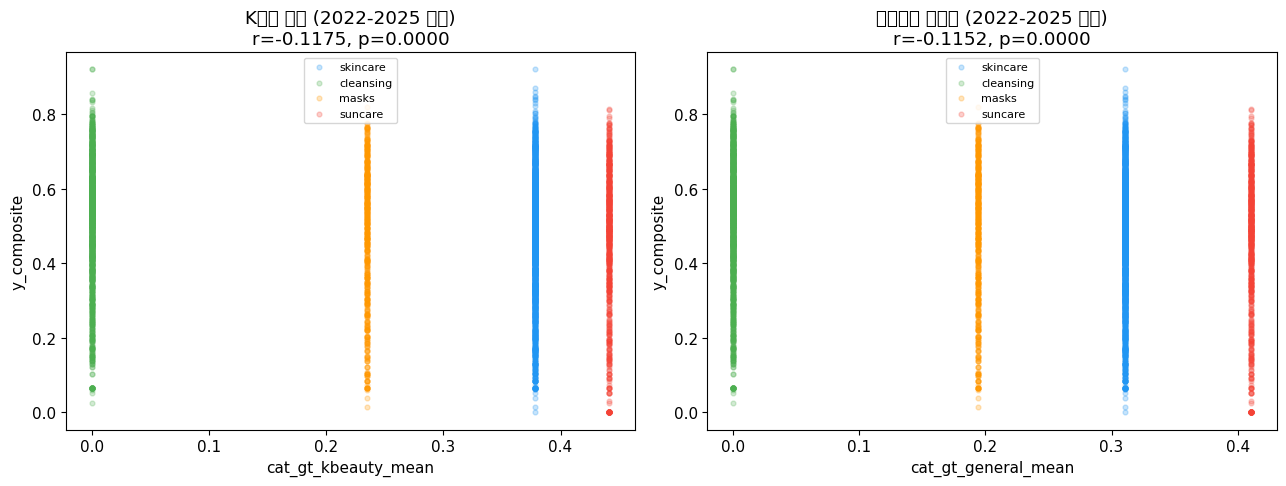


[참고] 이 피처는 카테고리 단위 상수값 → cat_* 원핫과 선형 관계 존재
       LightGBM에서 연속값으로 다른 피처와 교호작용 학습 가능


In [38]:
# ══ EDA: 카테고리 GT 트렌드 × y_composite 상관분석 ══════════════════

# 카테고리 트렌드 점수를 각 제품에 매핑 (같은 카테고리 = 같은 값)
for axis_name, feat_suffix in [('K뷰티_수요', 'kbeauty'), ('트렌드', 'general')]:
    mean_map  = {cat: cat_trend_stats[(cat, axis_name)]['mean']  for cat in cat_ko_map}
    slope_map = {cat: cat_trend_stats[(cat, axis_name)]['slope'] for cat in cat_ko_map}
    df_y[f'cat_gt_{feat_suffix}_mean']  = df_y['target_category'].map(mean_map).fillna(0)
    df_y[f'cat_gt_{feat_suffix}_slope'] = df_y['target_category'].map(slope_map).fillna(0)

cat_gt_feat_cols = [
    'cat_gt_kbeauty_mean', 'cat_gt_kbeauty_slope',
    'cat_gt_general_mean', 'cat_gt_general_slope'
]

print('=== 카테고리 GT 트렌드 × y_composite 상관분석 ===\n')
print(f"{'피처':<28} {'n':>5}  {'Pearson r':>10}  {'p':>8}  {'유의'}")
print('-' * 62)
for feat in cat_gt_feat_cols:
    r, p = stats.pearsonr(df_y[feat], df_y['y_composite'])
    sig = '✅ 유의' if p < 0.05 else '❌ 비유의'
    print(f'{feat:<28} {len(df_y):>5}  {r:>+10.4f}  {p:>8.4f}  {sig}')

print('\n=== 카테고리별 트렌드 점수 vs 평균 y_composite ===')
print(f"{'카테고리':<12} {'K뷰티 점수':>10} {'일반 점수':>10} {'y_mean':>8} {'n':>5}")
print('-' * 52)
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    sub = df_y[df_y['target_category'] == cat]
    kb = cat_trend_stats.get((cat, 'K뷰티_수요'), {'mean': 0})['mean']
    ge = cat_trend_stats.get((cat, '트렌드'), {'mean': 0})['mean']
    print(f'{cat:<12} {kb:>10.4f} {ge:>10.4f} {sub["y_composite"].mean():>8.4f} {len(sub):>5}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cat_colors = {'skincare': '#2196F3', 'cleansing': '#4CAF50', 'masks': '#FF9800', 'suncare': '#F44336'}
for ax, feat, label in zip(
    axes,
    ['cat_gt_kbeauty_mean', 'cat_gt_general_mean'],
    ['K뷰티 수요 (2022-2025 평균)', '카테고리 트렌드 (2022-2025 평균)']
):
    for cat, color in cat_colors.items():
        sub = df_y[df_y['target_category'] == cat]
        ax.scatter(sub[feat], sub['y_composite'], alpha=0.25, s=12, color=color, label=cat)
    r, p = stats.pearsonr(df_y[feat], df_y['y_composite'])
    ax.set_xlabel(feat)
    ax.set_ylabel('y_composite')
    ax.set_title(f'{label}\nr={r:+.4f}, p={p:.4f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('\n[참고] 이 피처는 카테고리 단위 상수값 → cat_* 원핫과 선형 관계 존재')
print('       LightGBM에서 연속값으로 다른 피처와 교호작용 학습 가능')


In [39]:
# 카테고리별 맨앞에 자주 나오는 액티브 성분 분석
# 성분_1~3 위치에서 가장 빈번한 성분 추출

ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
TOP_N = 15  # 카테고리당 top 성분 수
TOP_POS = 5  # 앞 몇 번째 위치까지 분석

cat_top_ings = {}  # {category: [(ingredient, freq_pct, mean_position), ...]}

print('=== 카테고리별 Top 액티브 성분 (앞 5개 위치 기준) ===\n')

for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    sub = df_y[df_y['target_category'] == cat].copy()
    if len(sub) == 0:
        continue

    # 앞 TOP_POS 위치 성분만 추출하여 빈도 집계
    front_cols = ing_cols[:TOP_POS]
    ing_counter = {}
    ing_positions = {}

    for _, row in sub[front_cols].iterrows():
        seen = set()
        for i, v in enumerate(row):
            if pd.notna(v) and str(v).strip():
                ing = str(v).strip().lower()
                if ing not in seen:
                    ing_counter[ing] = ing_counter.get(ing, 0) + 1
                    ing_positions.setdefault(ing, []).append(i + 1)  # 1-based
                    seen.add(ing)

    n = len(sub)
    top_ings = sorted(ing_counter.items(), key=lambda x: -x[1])[:TOP_N]
    cat_top_ings[cat] = []

    print(f'[{cat}]  (n={n})')
    print(f'  {"성분":<35} {"빈도":>6}  {"커버리지":>8}  {"평균위치":>8}')
    print('  ' + '-' * 62)
    for ing, cnt in top_ings:
        pct = cnt / n * 100
        avg_pos = np.mean(ing_positions[ing])
        cat_top_ings[cat].append((ing, pct, avg_pos))
        print(f'  {ing:<35} {cnt:>6}  {pct:>7.1f}%  {avg_pos:>8.2f}')
    print()

=== 카테고리별 Top 액티브 성분 (앞 5개 위치 기준) ===

[skincare]  (n=1973)
  성분                                      빈도      커버리지      평균위치
  --------------------------------------------------------------
  sodium hyaluronate                     676     34.3%      2.92
  niacinamide                            513     26.0%      1.71
  tocopherol                             456     23.1%      2.94
  tocopheryl acetate                     261     13.2%      2.62
  caffeine                               249     12.6%      2.65
  ceramide np                            203     10.3%      2.71
  panthenol                              200     10.1%      2.62
  retinol                                181      9.2%      2.34
  adenosine                              144      7.3%      3.69
  allantoin                              134      6.8%      2.94
  vitamin c                              118      6.0%      2.36
  panthenolhyaluronic acid               104      5.3%      2.63
  camellia sinensis leaf extra

In [40]:
# 카테고리별 Top 성분 × y_composite 상관분석
# position score = 1 - (idx / total_active)  when present
#                = -1                          when absent

ing_cols = [c for c in df_y.columns if c.startswith('성분_')]

def compute_position_score(df, ing_cols, pattern):
    """성분 패턴의 정규화 위치 반환. 없으면 -1."""
    total = df[ing_cols].notna().sum(axis=1).clip(lower=1)
    idx_s = df[ing_cols].apply(
        lambda row: next(
            (i for i, v in enumerate(row) if pd.notna(v) and pattern in str(v).lower()),
            -1
        ), axis=1
    )
    return np.where(idx_s >= 0, 1 - idx_s / total, -1)

corr_rows = []

print('=== 카테고리별 Top 성분 position × y_composite 상관분석 ===\n')
print(f'{"카테고리":<12} {"성분":<35} {"n":>5} {"커버리지":>8} {"Pearson r":>10} {"p":>8} {"유의"}' )
print('-' * 90)

sig_features = []

for cat, top_list in cat_top_ings.items():
    sub = df_y[df_y['target_category'] == cat].copy()
    for ing, freq_pct, avg_pos in top_list:
        pos_scores = compute_position_score(sub, ing_cols, ing)
        sub_valid  = sub[pos_scores != -1].copy()
        pos_valid  = pos_scores[pos_scores != -1]
        cov = (pos_scores >= 0).mean() * 100

        if len(sub_valid) < 30:
            continue

        r, p = stats.pearsonr(pos_valid, sub_valid['y_composite'])
        sig = '✅' if p < 0.05 else '❌'
        print(f'{cat:<12} {ing:<35} {len(sub_valid):>5} {cov:>7.1f}%  {r:>+10.4f} {p:>8.4f}  {sig}')

        corr_rows.append({
            'category': cat, 'ingredient': ing,
            'n': len(sub_valid), 'coverage_%': round(cov, 1),
            'pearson_r': round(r, 4), 'p_value': round(p, 4),
            'significant': p < 0.05,
            'avg_front_position': round(avg_pos, 2),
        })
        if p < 0.05 and cov >= 5:
            sig_features.append((cat, ing, round(r, 4)))
    print()

corr_df = pd.DataFrame(corr_rows)
print(f'\n유의미(p<0.05, 커버리지>=5%) 성분 수: {len(sig_features)}개')
for cat, ing, r in sorted(sig_features, key=lambda x: -abs(x[2])):
    print(f'  [{cat}] {ing:<35}  r={r:+.4f}')

=== 카테고리별 Top 성분 position × y_composite 상관분석 ===

카테고리         성분                                      n     커버리지  Pearson r        p 유의
------------------------------------------------------------------------------------------
skincare     sodium hyaluronate                    988    50.1%     +0.0785   0.0136  ✅
skincare     niacinamide                           551    27.9%     -0.0853   0.0453  ✅
skincare     tocopherol                            841    42.6%     +0.1300   0.0002  ✅
skincare     tocopheryl acetate                    497    25.2%     -0.0155   0.7295  ❌
skincare     caffeine                              365    18.5%     +0.0167   0.7500  ❌
skincare     ceramide np                           299    15.2%     +0.1567   0.0066  ✅
skincare     panthenol                             388    19.7%     -0.0872   0.0864  ❌
skincare     retinol                               208    10.5%     -0.0456   0.5128  ❌
skincare     adenosine                             277    14.0%     

In [41]:
# # 평균위치 ≤ 2.0 성분 (앞에 일관되게 등장하는 성분) × y_composite 상관분석

# ing_cols = [c for c in df_y.columns if c.startswith('성분_')]

# print('=== 평균위치 ≤ 2.0 성분 × y_composite 상관분석 ===\n')
# print(f'{"카테고리":<12} {"성분":<40} {"커버리지":>8} {"avg_pos":>8} {"Pearson r":>10} {"p":>8} {"유의"}')
# print('-' * 98)

# early_sig_features = []

# for cat, top_list in cat_top_ings.items():
#     sub = df_y[df_y['target_category'] == cat].copy()
#     printed_cat = False
#     for ing, freq_pct, avg_pos in top_list:
#         if avg_pos > 2.0:
#             continue
#         pos_scores = compute_position_score(sub, ing_cols, ing)
#         sub_valid  = sub[pos_scores != -1].copy()
#         pos_valid  = pos_scores[pos_scores != -1]
#         cov = (pos_scores >= 0).mean() * 100

#         if len(sub_valid) < 20:
#             continue

#         r, p = stats.pearsonr(pos_valid, sub_valid['y_composite'])
#         sig = '✅' if p < 0.05 else '❌'
#         print(f'{cat:<12} {ing:<40} {cov:>7.1f}%  {avg_pos:>8.2f}  {r:>+10.4f}  {p:>8.4f}  {sig}')

#         if p < 0.05:
#             early_sig_features.append((cat, ing, avg_pos, round(r, 4)))

# print(f'\n유의미(p<0.05) 성분: {len(early_sig_features)}개')
# for cat, ing, avg_pos, r in sorted(early_sig_features, key=lambda x: -abs(x[3])):
#     print(f'  [{cat}] {ing:<40} avg_pos={avg_pos:.2f}  r={r:+.4f}')

In [42]:
# # SPF_Index × y_composite 상관분석

# spf_vals = pd.to_numeric(df_y['SPF_Index'], errors='coerce')
# spf_mask = spf_vals.notna() & (spf_vals > 0)  # SPF 있는 제품만

# print('=== SPF_Index × y_composite 상관분석 ===\n')
# print(f'SPF 있는 제품: {spf_mask.sum()}개 / 전체 {len(df_y)}개 ({spf_mask.mean()*100:.1f}%)')

# r_all, p_all = stats.pearsonr(spf_vals[spf_mask], df_y.loc[spf_mask, 'y_composite'])
# print(f'\n[SPF>0 전체]  n={spf_mask.sum()}  r={r_all:+.4f}  p={p_all:.4f}  {"✅ 유의" if p_all < 0.05 else "❌ 비유의"}')

# # 카테고리별
# print()
# print(f'{"카테고리":<12} {"n":>5}  {"Pearson r":>10}  {"p":>8}  유의')
# print('-' * 50)
# for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
#     cat_mask = (df_y['target_category'] == cat) & spf_mask
#     n = cat_mask.sum()
#     if n < 20:
#         print(f'{cat:<12} {n:>5}  (샘플 부족)')
#         continue
#     r, p = stats.pearsonr(spf_vals[cat_mask], df_y.loc[cat_mask, 'y_composite'])
#     print(f'{cat:<12} {n:>5}  {r:>+10.4f}  {p:>8.4f}  {"✅" if p < 0.05 else "❌"}')

# # SPF 구간별 평균 y값
# print('\nSPF 구간별 평균 y_composite:')
# spf_bins = pd.cut(spf_vals[spf_mask], bins=[0,15,30,50,9999],
#                   labels=['SPF1-15', 'SPF16-30', 'SPF31-50', 'SPF50+'])
# grp = df_y.loc[spf_mask].groupby(spf_bins, observed=True)['y_composite'].agg(['mean','count'])
# print(grp.rename(columns={'mean':'avg_y','count':'n'}).round(4).to_string())

In [43]:
# ══ EDA 1: 성분 조합 피처 × y_composite ══════════════════════
from scipy.stats import mannwhitneyu

ing_cols_eda = [c for c in df_y.columns if c.startswith('성분_')]
ing_lower_eda = df_y[ing_cols_eda].fillna('').apply(lambda r: ' '.join(r).lower(), axis=1)

combos = {
    # 글로벌 트렌드 조합
    'niacinamide + ceramide':    ('niacinamide',   'ceramide'),
    'niacinamide + hyaluronic':  ('niacinamide',   'hyaluronic acid'),
    'retinol + niacinamide':     ('retinol',        'niacinamide'),
    'vitamin_c + tocopherol':    ('ascorbic',       'tocopherol'),
    'aha + bha':                 ('glycolic acid',  'salicylic acid'),
    'centella + niacinamide':    ('centella',       'niacinamide'),
    'peptide + ceramide':        ('peptide',        'ceramide'),
    'retinol + peptide':         ('retinol',        'peptide'),
    'caffeine + niacinamide':    ('caffeine',       'niacinamide'),
    'adenosine + niacinamide':   ('adenosine',      'niacinamide'),
    # 클렌징 특화
    'amino_surf + niacinamide':  ('cocoyl',         'niacinamide'),
    'salicylic + glycolic':      ('salicylic acid', 'glycolic acid'),
    # 선케어 특화
    'zinc + niacinamide':        ('zinc oxide',     'niacinamide'),
    'homosalate + niacinamide':  ('homosalate',     'niacinamide'),
}

print(f'{"조합":<35} {"커버리지":>8} {"y(있음)":>9} {"y(없음)":>9} {"차이":>8} {"p":>8} {"유의"}')
print('-' * 95)

sig_combos = []
for name, (kw1, kw2) in combos.items():
    has_both = (ing_lower_eda.str.contains(kw1, regex=False) &
                ing_lower_eda.str.contains(kw2, regex=False))
    cov = has_both.mean() * 100
    if has_both.sum() < 20:
        print(f'{name:<35} {cov:>7.1f}%  (샘플 부족: {has_both.sum()}개)')
        continue

    y_yes = df_y.loc[has_both,  'y_composite']
    y_no  = df_y.loc[~has_both, 'y_composite']
    _, p  = mannwhitneyu(y_yes, y_no, alternative='two-sided')
    diff  = y_yes.mean() - y_no.mean()
    sig   = '✅' if p < 0.05 else '❌'
    print(f'{name:<35} {cov:>7.1f}%  {y_yes.mean():>9.4f}  {y_no.mean():>9.4f}  {diff:>+8.4f}  {p:>8.4f}  {sig}')
    if p < 0.05:
        sig_combos.append((name, kw1, kw2, round(diff, 4), round(cov, 1)))

print(f'\n유의미 조합 {len(sig_combos)}개:')
for name, kw1, kw2, diff, cov in sorted(sig_combos, key=lambda x: -abs(x[3])):
    print(f'  {name:<35}  diff={diff:+.4f}  cov={cov:.1f}%')

조합                                      커버리지     y(있음)     y(없음)       차이        p 유의
-----------------------------------------------------------------------------------------------
niacinamide + ceramide                  5.2%     0.4975     0.4821   +0.0154    0.0464  ✅
niacinamide + hyaluronic                3.3%     0.4342     0.4845   -0.0504    0.0120  ✅
retinol + niacinamide                   2.2%     0.5315     0.4818   +0.0497    0.0011  ✅
vitamin_c + tocopherol                  3.3%     0.4028     0.4856   -0.0829    0.0000  ✅
aha + bha                               1.0%     0.4200     0.4835   -0.0636    0.0402  ✅
centella + niacinamide                  2.6%     0.4180     0.4846   -0.0667    0.0005  ✅
peptide + ceramide                      2.9%     0.4263     0.4846   -0.0582    0.0000  ✅
retinol + peptide                       0.9%     0.4145     0.4835   -0.0690    0.0021  ✅
caffeine + niacinamide                  3.2%     0.4994     0.4823   +0.0170    0.2682  ❌
adenosin

In [44]:
# ══ EDA 2: 트렌드 성분 밀도 × y_composite ══════════════════════
ing_cols_eda2 = [c for c in df_y.columns if c.startswith('성분_')]
ing_lower_eda2 = df_y[ing_cols_eda2].fillna('').apply(lambda r: ' '.join(r).lower(), axis=1)

gt_keywords = list({
    'niacinamide', 'ceramide', 'sodium hyaluronate', 'retinol', 'peptide',
    'ascorbic', 'panthenol', 'tocopherol', 'caffeine', 'centella',
    'bakuchiol', 'azelaic acid', 'tranexamic acid', 'salicylic acid',
    'squalane', 'ectoin', 'zinc oxide',
})

# us_trend_count를 이 EDA 셀에서 직접 계산 (피쳐 생성 셀 이전이라서)
us_trend_count_eda = ing_lower_eda2.apply(
    lambda txt: sum(1 for kw in gt_keywords if kw in txt)
)
active_count_eda = df_y[ing_cols_eda2].notna().sum(axis=1).clip(lower=1)
df_y['trend_density']     = us_trend_count_eda / active_count_eda

# 앉 5개 위치 내 트렌드 성분 개수
top5_cols = ing_cols_eda2[:5]
def count_trend_in_top5(row):
    joined = ' '.join(str(v).lower() for v in row if pd.notna(v))
    return sum(1 for kw in gt_keywords if kw in joined)
df_y['top5_trend_count'] = df_y[top5_cols].apply(count_trend_in_top5, axis=1)

density_feats = ['trend_density', 'top5_trend_count']

print('=== 트렌드 성분 밀도 피쳐 × y_composite 상관분석 ===')
print(f'{"피쳐":<22} {"Pearson r":>10} {"p":>8} {"유의"}')
print('-' * 50)
for feat in density_feats:
    r, p = stats.pearsonr(df_y[feat], df_y['y_composite'])
    print(f'{feat:<22} {r:>+10.4f} {p:>8.4f} {"✅" if p < 0.05 else "❌"}')

print('=== 카테고리별 상관분석 ===')
print(f'{"카테고리":<12}', end='')
for feat in density_feats:
    print(f'  {feat:<22}', end='')
print()
print('-' * 70)
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    sub = df_y[df_y['target_category'] == cat]
    print(f'{cat:<12}', end='')
    for feat in density_feats:
        r, p = stats.pearsonr(sub[feat], sub['y_composite'])
        sig = '✅' if p < 0.05 else '  '
        print(f'  r={r:+.3f} p={p:.3f}{sig}    ', end='')
    print()

print(f'top5_trend_count 분포:')
print(df_y['top5_trend_count'].value_counts().sort_index().to_string())
print(f'trend_density 통계: mean={df_y["trend_density"].mean():.3f}  median={df_y["trend_density"].median():.3f}  max={df_y["trend_density"].max():.3f}')


=== 트렌드 성분 밀도 피쳐 × y_composite 상관분석 ===
피쳐                      Pearson r        p 유의
--------------------------------------------------
trend_density             +0.2557   0.0000 ✅
top5_trend_count          +0.1174   0.0000 ✅
=== 카테고리별 상관분석 ===
카테고리          trend_density           top5_trend_count      
----------------------------------------------------------------------
skincare      r=+0.256 p=0.000✅      r=+0.119 p=0.000✅    
cleansing     r=+0.258 p=0.000✅      r=+0.173 p=0.000✅    
masks         r=+0.524 p=0.000✅      r=+0.288 p=0.000✅    
suncare       r=-0.040 p=0.295        r=-0.094 p=0.013✅    
top5_trend_count 분포:
top5_trend_count
0     966
1    1541
2    1092
3     587
4     221
5      28
trend_density 통계: mean=0.409  median=0.333  max=1.000


In [45]:
# 피처 생성
# 1) 가격/카테고리/US트렌드 기본 피처
# 2) EDA에서 유의미한 성분 position 피처
# 3) 카테고리 특화 피처
# 4) 성분 조합 피처 (EDA 유의미)
# 5) 트렌드 밀도 교호작용

ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
ing_lower_series = df_y[ing_cols].fillna('').apply(lambda row: ' '.join(row).lower(), axis=1)

# 성분 개수
df_y['active_count'] = df_y[ing_cols].notna().sum(axis=1)

# 숫자형 강제 변환
df_y['공급가(USD)'] = pd.to_numeric(df_y['공급가(USD)'], errors='coerce').fillna(0)
df_y['SPF_Index']   = pd.to_numeric(df_y['SPF_Index'],   errors='coerce').fillna(0)

# 가격
df_y['log_price']         = np.log1p(df_y['공급가(USD)'])
df_y['price_rank_in_cat'] = df_y.groupby('target_category')['공급가(USD)'].rank(pct=True)
price_d = pd.get_dummies(
    pd.cut(df_y['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_y = pd.concat([df_y, price_d], axis=1)

# 카테고리 원핫
cat_d = pd.get_dummies(df_y['target_category'], prefix='cat').astype(int)
df_y = pd.concat([df_y, cat_d], axis=1)
for _c in ['skincare','cleansing','masks','suncare']:
    if f'cat_{_c}' not in df_y.columns:
        df_y[f'cat_{_c}'] = 0

# 카테고리(중) 원핫 (n>=50)
mid_cnt   = df_y['카테고리(중)'].value_counts()
valid_mid = mid_cnt[mid_cnt >= 50].index
df_y['cat_mid'] = df_y['카테고리(중)'].where(df_y['카테고리(중)'].isin(valid_mid), other='기타')
mid_d = pd.get_dummies(df_y['cat_mid'], prefix='mid').astype(int)
df_y = pd.concat([df_y, mid_d], axis=1)
mid_feat_cols = [c for c in df_y.columns if c.startswith('mid_')]

# US 트렌드 성분 이진 피처
gt_map = {
    'gt_niacinamide':       'niacinamide',
    'gt_ceramide':          'ceramide',
    'gt_sodium_hyaluronate':'sodium hyaluronate',
    'gt_retinol':           'retinol',
    'gt_peptide':           'peptide',
    'gt_vitamin_c':         'ascorbic',
    'gt_panthenol':         'panthenol',
    'gt_tocopherol':        'tocopherol',
    'gt_caffeine':          'caffeine',
    'gt_centella':          'centella',
    'gt_bakuchiol':         'bakuchiol',
    'gt_azelaic':           'azelaic acid',
    'gt_tranexamic':        'tranexamic acid',
    'gt_salicylic':         'salicylic acid',
    'gt_squalane':          'squalane',
    'gt_ectoin':            'ectoin',
    'gt_zinc_oxide':        'zinc oxide',
}
for feat, kw in gt_map.items():
    df_y[feat] = ing_lower_series.str.contains(kw, regex=False).astype(int)
gt_cols = list(gt_map.keys())
df_y['us_trend_count'] = df_y[gt_cols].sum(axis=1)
df_y['us_trend_ratio'] = df_y['us_trend_count'] / len(gt_cols)

# SPF
df_y['spf_tier'] = pd.cut(
    df_y['SPF_Index'], bins=[-1,0,30,50,9999], labels=[0,1,2,3]
).astype(float).fillna(0).astype(int)

# 클렌징 특화
df_y['is_amino_surfactant'] = ing_lower_series.str.contains(
    r'sodium cocoyl|potassium cocoyl|sodium lauroyl|cocoamidopropyl betaine|cocamidopropyl betaine',
    regex=True).astype(int)
df_y['is_sulfate']         = ing_lower_series.str.contains(
    r'sodium lauryl sulfate|sodium laureth sulfate', regex=True).astype(int)
df_y['is_salicylic']       = ing_lower_series.str.contains('salicylic acid', regex=False).astype(int)

# 선케어 특화
df_y['is_physical_filter'] = ing_lower_series.str.contains(
    r'zinc oxide|titanium dioxide', regex=True).astype(int)


# 클렌징 특화 — polyglyceryl 계 유화제 (음의 신호, p=0.001)
df_y['has_polyglyceryl'] = ing_lower_series.str.contains('polyglyceryl', regex=False).astype(int)


# 성분 조합 피처 (EDA 유의미: p<0.05, cov>=5%)
df_y['combo_adenosine_niacinamide'] = (
    ing_lower_series.str.contains('adenosine',  regex=False) &
    ing_lower_series.str.contains('niacinamide', regex=False)
).astype(int)
df_y['combo_vitc_tocopherol'] = (
    ing_lower_series.str.contains('ascorbic',   regex=False) &
    ing_lower_series.str.contains('tocopherol', regex=False)
).astype(int)

# 교호작용
df_y['interact_logprice_skincare']   = df_y['log_price'] * df_y['cat_skincare']
df_y['interact_logprice_cleansing']  = df_y['log_price'] * df_y['cat_cleansing']
df_y['interact_logprice_masks']      = df_y['log_price'] * df_y['cat_masks']
df_y['interact_logprice_suncare']    = df_y['log_price'] * df_y['cat_suncare']
df_y['interact_trend_skincare']      = df_y['us_trend_ratio'] * df_y['cat_skincare']
df_y['interact_trend_cleansing']     = df_y['us_trend_ratio'] * df_y['cat_cleansing']
df_y['interact_amino_cleansing']     = df_y['is_amino_surfactant'] * df_y['cat_cleansing']
df_y['interact_salicylic_cleansing'] = df_y['is_salicylic'] * df_y['cat_cleansing']
df_y['interact_physical_suncare']    = df_y['is_physical_filter'] * df_y['cat_suncare']
df_y['interact_spf_suncare']         = df_y['spf_tier'] * df_y['cat_suncare']
df_y['interact_trendcount_skincare'] = df_y['us_trend_count'] * df_y['cat_skincare']
df_y['interact_trendcount_cleansing']= df_y['us_trend_count'] * df_y['cat_cleansing']
df_y['interact_top5trend_cleansing'] = df_y['top5_trend_count'] * df_y['cat_cleansing']
df_y['interact_polyglyceryl_cleansing'] = df_y['has_polyglyceryl']   * df_y['cat_cleansing']
df_y['interact_niacinamide_cleansing']  = df_y['gt_niacinamide']          * df_y['cat_cleansing']
df_y['interact_hyaluronic_cleansing']   = df_y['gt_sodium_hyaluronate']   * df_y['cat_cleansing']


interact_cols = [
    'interact_logprice_skincare', 'interact_logprice_cleansing',
    'interact_logprice_masks',    'interact_logprice_suncare',
    'interact_trend_skincare',    'interact_trend_cleansing',
    'interact_amino_cleansing',   'interact_salicylic_cleansing',
    'interact_physical_suncare',  'interact_spf_suncare',
    'interact_trendcount_skincare', 'interact_trendcount_cleansing',
    'interact_top5trend_cleansing',
    'interact_polyglyceryl_cleansing',
    'interact_niacinamide_cleansing',
    'interact_hyaluronic_cleansing',
]

print('기본 피처 생성 완료')
print(f'  GT 트렌드 성분: {len(gt_cols)}개')
print(f'  us_trend_count: min={df_y["us_trend_count"].min():.0f}, max={df_y["us_trend_count"].max():.0f}, mean={df_y["us_trend_count"].mean():.2f}')
print(f'  카테고리(중) 원핫: {len(mid_feat_cols)}개')
print(f'  combo_adenosine_niacinamide: {df_y["combo_adenosine_niacinamide"].sum()}개 ({df_y["combo_adenosine_niacinamide"].mean()*100:.1f}%)')
print(f'  combo_vitc_tocopherol:       {df_y["combo_vitc_tocopherol"].sum()}개 ({df_y["combo_vitc_tocopherol"].mean()*100:.1f}%)')

기본 피처 생성 완료
  GT 트렌드 성분: 17개
  us_trend_count: min=0, max=9, mean=1.95
  카테고리(중) 원핫: 16개
  combo_adenosine_niacinamide: 183개 (4.1%)
  combo_vitc_tocopherol:       146개 (3.3%)


In [46]:
# # us_trend_count × y_composite 상관분석

# print('=== US 트렌드 성분 포함 개수 vs y_composite 상관분석 ===\n')

# # 전체
# r_all, p_all = stats.pearsonr(df_y['us_trend_count'], df_y['y_composite'])
# print(f'[전체]  n={len(df_y)}  Pearson r={r_all:+.4f}  p={p_all:.4f}  {"✅ 유의" if p_all < 0.05 else "❌ 비유의"}')

# # 카테고리별
# print()
# print(f'{"카테고리":<12} {"n":>5}  {"Pearson r":>10}  {"p":>8}  {"유의"}')
# print('-' * 50)
# for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
#     sub = df_y[df_y['target_category'] == cat]
#     if len(sub) < 30:
#         continue
#     r, p = stats.pearsonr(sub['us_trend_count'], sub['y_composite'])
#     print(f'{cat:<12} {len(sub):>5}  {r:>+10.4f}  {p:>8.4f}  {"✅" if p < 0.05 else "❌"}')

# # 분포 확인
# print(f'\nus_trend_count 분포:')
# print(df_y['us_trend_count'].value_counts().sort_index().to_string())
# print(f'\n카테고리별 평균 us_trend_count:')
# print(df_y.groupby('target_category')['us_trend_count'].mean().round(2).to_string())

# # 시각화
# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# # 전체: boxplot by count
# cnt_order = sorted(df_y['us_trend_count'].unique())
# data_by_cnt = [df_y.loc[df_y['us_trend_count'] == c, 'y_composite'].values for c in cnt_order]
# axes[0].boxplot(data_by_cnt, labels=cnt_order, patch_artist=True,
#                 boxprops=dict(facecolor='#90CAF9'))
# axes[0].set_xlabel('us_trend_count')
# axes[0].set_ylabel('y_composite')
# axes[0].set_title(f'us_trend_count vs y_composite (전체, r={r_all:+.3f})')

# # 카테고리별 mean y_composite by count
# cat_colors = {'skincare': '#2196F3', 'cleansing': '#4CAF50', 'masks': '#FF9800', 'suncare': '#F44336'}
# for cat, color in cat_colors.items():
#     sub = df_y[df_y['target_category'] == cat]
#     means = sub.groupby('us_trend_count')['y_composite'].mean()
#     axes[1].plot(means.index, means.values, marker='o', label=cat, color=color)
# axes[1].set_xlabel('us_trend_count')
# axes[1].set_ylabel('mean y_composite')
# axes[1].set_title('카테고리별 us_trend_count vs mean y_composite')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

In [47]:
# EDA 유의미 성분 Position 피처 생성

ing_cols = [c for c in df_y.columns if c.startswith('성분_')]

def make_position_feature(df, ing_cols, pattern):
    total = df[ing_cols].notna().sum(axis=1).clip(lower=1)
    idx_s = df[ing_cols].apply(
        lambda row: next(
            (i for i, v in enumerate(row) if pd.notna(v) and pattern in str(v).lower()),
            -1
        ), axis=1
    )
    return np.where(idx_s >= 0, 1 - idx_s / total, -1)

# 유의미 성분 목록 (sig_features 기반 자동 구성)
position_targets = {}
for cat, ing, r in sig_features:
    key = re.sub(r'[^a-z0-9]+', '_', ing.strip().lower()).strip('_')
    position_targets[key] = ing

# 항상 포함할 주요 성분
mandatory = {
    'niacinamide':    'niacinamide',
    'ceramide':       'ceramide',
    'hyaluronic_acid':'hyaluronic acid',
    'retinol':        'retinol',
    'salicylic_acid': 'salicylic acid',
    'zinc_oxide':     'zinc oxide',
    'vitamin_c':      'ascorbic',
    'homosalate':     'homosalate',   # suncare 특화 (r=-0.43, avg_pos=1.11)
}
position_targets.update(mandatory)

pos_feat_cols = []
for feat_key, pattern in position_targets.items():
    col = f'pos_{feat_key}'
    df_y[col] = make_position_feature(df_y, ing_cols, pattern)
    cov = (df_y[col] >= 0).mean() * 100
    pos_feat_cols.append(col)
    print(f'  {col:<50} 커버리지: {cov:.1f}%')

# Category × Position 교호작용
pos_cat_interact = []
cat_map_for_pos = {
    'niacinamide':    ['cat_skincare', 'cat_cleansing', 'cat_masks'],
    'ceramide':       ['cat_skincare', 'cat_masks'],
    'hyaluronic_acid':['cat_skincare', 'cat_masks'],
    'retinol':        ['cat_skincare'],
    'salicylic_acid': ['cat_cleansing'],
    'zinc_oxide':     ['cat_suncare'],
    'vitamin_c':      ['cat_skincare'],
    'homosalate':     ['cat_suncare'],  # suncare에서만 유의
}
for feat_key, cat_cols in cat_map_for_pos.items():
    pos_col = f'pos_{feat_key}'
    if pos_col not in df_y.columns: continue
    for cat_col in cat_cols:
        if cat_col not in df_y.columns: continue
        new_col = f'{pos_col}_x_{cat_col.replace("cat_","")}'
        df_y[new_col] = df_y[cat_col] * df_y[pos_col]
        cov = (df_y[new_col] > 0).mean() * 100
        if cov >= 1.0:
            pos_cat_interact.append(new_col)
            print(f'  {new_col:<55} 커버리지: {cov:.1f}%')

print(f'\nPosition 피처: {len(pos_feat_cols)}개')
print(f'Position×Cat 교호작용: {len(pos_cat_interact)}개')

  pos_sodium_hyaluronate                             커버리지: 39.3%
  pos_niacinamide                                    커버리지: 19.3%
  pos_tocopherol                                     커버리지: 38.7%
  pos_ceramide_np                                    커버리지: 14.0%
  pos_adenosine                                      커버리지: 8.1%
  pos_allantoin                                      커버리지: 10.8%
  pos_camellia_sinensis_leaf_extract                 커버리지: 7.4%
  pos_sodium_methyl_cocoyl_taurate                   커버리지: 6.2%
  pos_salicylic_acid                                 커버리지: 11.7%
  pos_homosalate                                     커버리지: 3.9%
  pos_zinc_oxide                                     커버리지: 4.7%
  pos_ceramide                                       커버리지: 16.6%
  pos_hyaluronic_acid                                커버리지: 7.8%
  pos_retinol                                        커버리지: 5.0%
  pos_vitamin_c                                      커버리지: 6.1%
  pos_niacinamide_x_skincare     

In [48]:
# GT 구글트렌드 트렌드 피처 (gt_* binary + pos_* 활용)
gt_col_to_kw = {
    "gt_niacinamide":        "niacinamide",
    "gt_ceramide":           "ceramide",
    "gt_sodium_hyaluronate": "hyaluronic acid",
    "gt_retinol":            "retinol",
    "gt_peptide":            "peptide",
    "gt_vitamin_c":          "vitamin c",
    "gt_panthenol":          "panthenol",
    "gt_centella":           "centella asiatica",
    "gt_bakuchiol":          "bakuchiol",
    "gt_azelaic":            "azelaic acid",
    "gt_tranexamic":         "tranexamic acid",
    "gt_salicylic":          "salicylic acid",
    "gt_squalane":           "squalane",
}
valid_map = {col: kw for col, kw in gt_col_to_kw.items()
             if col in df_y.columns and kw in gt_trend_stats}

presence   = df_y[list(valid_map.keys())].copy()
recent_lvl = pd.Series({col: gt_trend_stats[kw]["recent_12m"] for col, kw in valid_map.items()})
slope_lvl  = pd.Series({col: gt_trend_stats[kw]["slope_12m"]  for col, kw in valid_map.items()})

recent_mat = presence.multiply(recent_lvl)
slope_mat  = presence.multiply(slope_lvl)
n_present  = presence.sum(axis=1).clip(lower=1)

df_y["trend_max_recent"]   = recent_mat.max(axis=1)
df_y["trend_avg_recent"]   = recent_mat.sum(axis=1) / n_present
df_y["trend_rising_count"] = (slope_mat > 0).sum(axis=1).astype(float)
df_y["trend_avg_slope"]    = slope_mat.sum(axis=1) / n_present

# 위치 가중 트렌드 피처
gt_col_to_pos = {
    "gt_niacinamide":        "pos_niacinamide",
    "gt_ceramide":           "pos_ceramide",
    "gt_sodium_hyaluronate": "pos_hyaluronic_acid",
    "gt_retinol":            "pos_retinol",
    "gt_vitamin_c":          "pos_vitamin_c",
    "gt_salicylic":          "pos_salicylic_acid",
}
trend_pos_w = pd.Series(0.0, index=df_y.index)
for gt_col, pos_col in gt_col_to_pos.items():
    if gt_col not in valid_map or pos_col not in df_y.columns:
        continue
    trend_pos_w += df_y[pos_col].clip(lower=0) * gt_trend_stats[valid_map[gt_col]]["recent_12m"]
df_y["trend_pos_weighted"] = trend_pos_w

gt_trend_feat_cols = ["trend_max_recent", "trend_avg_recent",
                       "trend_rising_count", "trend_avg_slope", "trend_pos_weighted"]
print("GT 트렌드 피처 완료 (5개)")
for col in gt_trend_feat_cols:
    print(f"  {col:<25} mean={df_y[col].mean():.4f}  max={df_y[col].max():.4f}")


GT 트렌드 피처 완료 (5개)
  trend_max_recent          mean=0.3401  max=0.8300
  trend_avg_recent          mean=0.3191  max=0.8300
  trend_rising_count        mean=1.3993  max=7.0000
  trend_avg_slope           mean=0.0395  max=0.0701
  trend_pos_weighted        mean=0.2059  max=1.5727


In [49]:
# 클렌징 성분 기반 세분화 피처 + 상관분석
# 클렌징 top 액티브 성분 분석 기반

ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
ing_lower = df_y[ing_cols].fillna('').apply(lambda r: ' '.join(r).lower(), axis=1)
cl_mask = df_y['target_category'] == 'cleansing'

# 1. 프리미엄 아미노산 계면활성제 (sodium cocoyl glycinate / taurate / glutamate)
#    → 현재 is_amino_surfactant보다 더 세분화된 고급 계면활성제
df_y['is_premium_amino_surf'] = ing_lower.str.contains(
    r'sodium cocoyl glycinate|sodium methyl cocoyl taurate|sodium cocoyl glutamate',
    regex=True).astype(int)

# 2. 트리트먼트 클렌저 (AHA/BHA 포함 → 각질/모공 케어 목적)
df_y['is_treatment_cleanser'] = ing_lower.str.contains(
    r'glycolic acid|lactic acid|mandelic acid', regex=True).astype(int)

# 3. 보습 클렌저 (hyaluronate + panthenol + allantoin → 스키니피케이션)
df_y['has_barrier_in_cleanser'] = (
    ing_lower.str.contains('sodium hyaluronate', regex=False) |
    ing_lower.str.contains('panthenol', regex=False) |
    ing_lower.str.contains('allantoin', regex=False)
).astype(int)

# 4. 계면활성제 등급 (ordinal: 0=없음, 1=sulfate, 2=betaine/일반, 3=premium amino)
def surfactant_grade(text):
    if any(k in text for k in ['sodium cocoyl glycinate', 'sodium methyl cocoyl taurate', 'sodium cocoyl glutamate']):
        return 3
    if any(k in text for k in ['sodium cocoyl', 'potassium cocoyl', 'sodium lauroyl', 'cocoamidopropyl betaine', 'cocamidopropyl betaine']):
        return 2
    if any(k in text for k in ['sodium lauryl sulfate', 'sodium laureth sulfate']):
        return 1
    return 0

df_y['surfactant_grade'] = ing_lower.apply(surfactant_grade)

# 5. 교호작용: 프리미엄 계면활성제 × 가격
df_y['interact_premium_surf_price'] = df_y['is_premium_amino_surf'] * df_y['log_price']

cleansing_ing_feat_cols = [
    'is_premium_amino_surf',
    'is_treatment_cleanser',
    'has_barrier_in_cleanser',
    'surfactant_grade',
    'interact_premium_surf_price',
]

# 상관분석 (클렌징 전체 + 클렌징 내부)
print('=== 클렌징 성분 피처 × y_composite 상관분석 ===')
print(f"{'피처':<30} {'전체 n':>6}  {'r(전체)':>8}  {'r(클렌징)':>10}  {'p(클렌징)':>10}  유의")
print('-' * 78)
for feat in cleansing_ing_feat_cols:
    r_all, _ = stats.pearsonr(df_y[feat], df_y['y_composite'])
    cl_sub = df_y[cl_mask]
    r_cl, p_cl = stats.pearsonr(cl_sub[feat], cl_sub['y_composite'])
    sig = '✅' if p_cl < 0.05 else '❌'
    print(f"{feat:<30} {len(df_y):>6}  {r_all:>+8.4f}  {r_cl:>+10.4f}  {p_cl:>10.4f}  {sig}")

print('\n=== 클렌징 내 피처 분포 ===')
cl_sub = df_y[cl_mask]
for feat in cleansing_ing_feat_cols:
    if df_y[feat].nunique() <= 4:
        print(f"\n[{feat}]")
        vc = cl_sub[feat].value_counts().sort_index()
        for val, cnt in vc.items():
            y_mean = cl_sub.loc[cl_sub[feat]==val, 'y_composite'].mean()
            print(f"  {val}: {cnt}개 ({cnt/len(cl_sub)*100:.1f}%)  y_mean={y_mean:.4f}")
    else:
        r, p = stats.pearsonr(cl_sub[feat], cl_sub['y_composite'])
        print(f"[{feat}] mean={cl_sub[feat].mean():.3f}  r={r:+.4f}  p={p:.4f}")


=== 클렌징 성분 피처 × y_composite 상관분석 ===
피처                               전체 n     r(전체)      r(클렌징)      p(클렌징)  유의
------------------------------------------------------------------------------
is_premium_amino_surf            4435   +0.1723     +0.2760      0.0000  ✅
is_treatment_cleanser            4435   -0.0508     -0.0585      0.0376  ✅
has_barrier_in_cleanser          4435   +0.0012     +0.0655      0.0198  ✅
surfactant_grade                 4435   +0.1595     +0.2511      0.0000  ✅
interact_premium_surf_price      4435   +0.1637     +0.2597      0.0000  ✅

=== 클렌징 내 피처 분포 ===

[is_premium_amino_surf]
  0: 784개 (62.0%)  y_mean=0.4801
  1: 481개 (38.0%)  y_mean=0.5739

[is_treatment_cleanser]
  0: 1204개 (95.2%)  y_mean=0.5180
  1: 61개 (4.8%)  y_mean=0.4729

[has_barrier_in_cleanser]
  0: 648개 (51.2%)  y_mean=0.5052
  1: 617개 (48.8%)  y_mean=0.5269

[surfactant_grade]
  0: 747개 (59.1%)  y_mean=0.4837
  2: 37개 (2.9%)  y_mean=0.4086
  3: 481개 (38.0%)  y_mean=0.5739
[interact_premium_sur

In [50]:
# Suncare / Skincare 전용 피처 + 상관분석

ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
ing_lower = df_y[ing_cols].fillna('').apply(lambda r: ' '.join(r).lower(), axis=1)

# ── SUNCARE ─────────────────────────────────────────────
sc_mask = df_y['target_category'] == 'suncare'

# 1. 화학적 자외선차단제 (homosalate, octisalate, octinoxate, avobenzone)
df_y['is_chemical_filter'] = ing_lower.str.contains(
    r'homosalate|octisalate|octinoxate|avobenzone|oxybenzone|octocrylene',
    regex=True).astype(int)

# 2. 하이브리드 필터 (물리적 + 화학적 동시 포함)
df_y['is_hybrid_filter'] = (
    (df_y['is_physical_filter'] == 1) & (df_y['is_chemical_filter'] == 1)
).astype(int)

# 3. SPF 50 이상 (고차단)
df_y['spf_50plus'] = (df_y['SPF_Index'] >= 50).astype(int)

# 4. 교호작용
df_y['interact_chemical_suncare']      = df_y['is_chemical_filter'] * df_y['cat_suncare']
df_y['interact_hybrid_suncare']        = df_y['is_hybrid_filter']   * df_y['cat_suncare']
df_y['interact_spf50_suncare']         = df_y['spf_50plus']         * df_y['cat_suncare']
df_y['interact_physical_price_suncare']= df_y['is_physical_filter'] * df_y['log_price'] * df_y['cat_suncare']

suncare_feat_cols = [
    'is_chemical_filter', 'is_hybrid_filter', 'spf_50plus',
    'interact_chemical_suncare', 'interact_hybrid_suncare',
    'interact_spf50_suncare', 'interact_physical_price_suncare',
]

print('=== Suncare 피처 × y_composite 상관분석 ===')
sc_sub = df_y[sc_mask]
print(f"{'피처':<35} {'r(전체)':>8}  {'r(suncare)':>10}  {'p':>8}  유의")
print('-' * 70)
for feat in suncare_feat_cols:
    r_all, _ = stats.pearsonr(df_y[feat], df_y['y_composite'])
    r_sc, p_sc = stats.pearsonr(sc_sub[feat], sc_sub['y_composite'])
    print(f"{feat:<35} {r_all:>+8.4f}  {r_sc:>+10.4f}  {p_sc:>8.4f}  {'✅' if p_sc < 0.05 else '❌'}")

# ── SKINCARE ────────────────────────────────────────────
sk_mask = df_y['target_category'] == 'skincare'

# 1. 레티놀 계열 (강력한 항노화 성분)
df_y['has_retinol'] = ing_lower.str.contains(
    r'retinol|retinyl palmitate|retinaldehyde|hydroxypinacolone retinoate',
    regex=True).astype(int)

# 2. 펩타이드 (항노화 트렌드 성분)
df_y['has_peptide'] = ing_lower.str.contains(
    r'peptide|oligopeptide|hexapeptide|tripeptide|tetrapeptide',
    regex=True).astype(int)

# 3. 발효 성분 (K-뷰티 특화)
df_y['has_ferment'] = ing_lower.str.contains(
    r'ferment|bifida|lactobacillus|galactomyces',
    regex=True).astype(int)

# 4. 교호작용: 세럼/에센스 × 레티놀, 크림 × 세라마이드
mid_serum = 'mid_essence/serum/ampoule'
mid_cream  = 'mid_cream'
if mid_serum in df_y.columns:
    df_y['interact_serum_retinol']  = df_y[mid_serum] * df_y['has_retinol']
    df_y['interact_serum_peptide']  = df_y[mid_serum] * df_y['has_peptide']
if mid_cream in df_y.columns:
    df_y['interact_cream_ceramide'] = df_y[mid_cream] * df_y['gt_ceramide']

skincare_feat_cols = ['has_retinol', 'has_peptide', 'has_ferment']
if mid_serum in df_y.columns:
    skincare_feat_cols += ['interact_serum_retinol', 'interact_serum_peptide']
if mid_cream in df_y.columns:
    skincare_feat_cols += ['interact_cream_ceramide']

print('\n=== Skincare 피처 × y_composite 상관분석 ===')
sk_sub = df_y[sk_mask]
print(f"{'피처':<30} {'r(전체)':>8}  {'r(skincare)':>10}  {'p':>8}  유의")
print('-' * 65)
for feat in skincare_feat_cols:
    if feat not in df_y.columns: continue
    r_all, _ = stats.pearsonr(df_y[feat], df_y['y_composite'])
    r_sk, p_sk = stats.pearsonr(sk_sub[feat], sk_sub['y_composite'])
    print(f"{feat:<30} {r_all:>+8.4f}  {r_sk:>+10.4f}  {p_sk:>8.4f}  {'✅' if p_sk < 0.05 else '❌'}")


=== Suncare 피처 × y_composite 상관분석 ===
피처                                     r(전체)  r(suncare)         p  유의
----------------------------------------------------------------------
is_chemical_filter                   +0.0526     +0.1976    0.0000  ✅
is_hybrid_filter                     +0.0846     +0.2488    0.0000  ✅
spf_50plus                           -0.1251     -0.2903    0.0000  ✅
interact_chemical_suncare            +0.0537     +0.1976    0.0000  ✅
interact_hybrid_suncare              +0.0866     +0.2488    0.0000  ✅
interact_spf50_suncare               -0.1233     -0.2903    0.0000  ✅
interact_physical_price_suncare      +0.0248     +0.1380    0.0003  ✅

=== Skincare 피처 × y_composite 상관분석 ===
피처                                r(전체)  r(skincare)         p  유의
-----------------------------------------------------------------
has_retinol                     +0.0367     +0.1142    0.0000  ✅
has_peptide                     -0.1263     -0.1295    0.0000  ✅
has_ferment                

In [51]:
from sklearn.model_selection import train_test_split, KFold

feat_cols = (
    ['price_low', 'price_mid', 'price_high', 'log_price', 'price_rank_in_cat']
    + ['SPF_Index', 'spf_tier']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols
    + gt_cols + ['us_trend_count', 'us_trend_ratio']
    + ['top5_trend_count']
    + pos_feat_cols
    + pos_cat_interact
    + ['is_amino_surfactant', 'is_sulfate', 'is_salicylic', 'is_physical_filter']
    + ['combo_adenosine_niacinamide', 'combo_vitc_tocopherol']
    + interact_cols
    + gt_trend_feat_cols
    + cat_gt_feat_cols
    + cleansing_ing_feat_cols
    + suncare_feat_cols
    + skincare_feat_cols
)
feat_cols = [c for c in feat_cols if c in df_y.columns]

# 1. target 계산 전 인덱스 분리 (누수 방지)
all_idx = np.arange(len(df_y))
train_idx, test_idx = train_test_split(
    all_idx, test_size=0.2,
    stratify=df_y['target_category'],
    random_state=42
)

# 2. Train 기준으로 카테고리별 30/70 threshold 계산
df_train_all = df_y.loc[train_idx]
cat_thresholds = {}
print(f'{"카테고리":<14} {"th_lo":>8} {"th_hi":>8}')
print('-' * 35)
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    sub = df_train_all[df_train_all['target_category'] == cat]['y_composite']
    if len(sub) == 0:
        continue
    th_lo, th_hi = sub.quantile(0.30), sub.quantile(0.70)
    cat_thresholds[cat] = (th_lo, th_hi)
    print(f'{cat:<14} {th_lo:>8.4f} {th_hi:>8.4f}')

# 3. Train threshold 기준으로 전체 target 할당
df_y['target'] = -1
for cat, (th_lo, th_hi) in cat_thresholds.items():
    mask = df_y['target_category'] == cat
    df_y.loc[mask & (df_y['y_composite'] >= th_hi), 'target'] = 1
    df_y.loc[mask & (df_y['y_composite'] <= th_lo), 'target'] = 0

# 4. middle 제거 후 분리
non_mid  = df_y['target'] != -1
df_train = df_y[df_y.index.isin(train_idx) & non_mid].copy()
df_test  = df_y[df_y.index.isin(test_idx)  & non_mid].copy()

X_train = df_train[feat_cols].fillna(0).astype(float).values
y_train = df_train['target'].values
X_test  = df_test[feat_cols].fillna(0).astype(float).values
y_test  = df_test['target'].values
test_cats_series = df_test['target_category'].reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'\n전체 피처 수: {len(feat_cols)}개')
print(f'Train: {len(y_train)}개  (긍정={y_train.sum()}, 부정={len(y_train)-y_train.sum()})')
print(f'Test:  {len(y_test)}개   (긍정={y_test.sum()}, 부정={len(y_test)-y_test.sum()})')

auc_base = cross_validate(
    LGBMClassifier(random_state=42, verbose=-1),
    X_train, y_train, cv=skf, scoring=['roc_auc']
)['test_roc_auc'].mean()
print(f'\n베이스라인 Train CV AUC: {auc_base:.4f}')


카테고리              th_lo    th_hi
-----------------------------------
skincare         0.4016   0.5642
cleansing        0.4441   0.6060
masks            0.3668   0.6082
suncare          0.4100   0.5823

전체 피처 수: 126개
Train: 2132개  (긍정=1066, 부정=1066)
Test:  500개   (긍정=260, 부정=240)



베이스라인 Train CV AUC: 0.8085


In [52]:
from lightgbm import LGBMClassifier
# Importance Pruning
low_cov_gt = [c for c in gt_cols if c in feat_cols and df_y[feat_cols][c].mean() < 0.05]
feat_cols_p = [c for c in feat_cols if c not in low_cov_gt]
print(f'커버리지 5% 미만 GT 제거 ({len(low_cov_gt)}개): {low_cov_gt}')

feat_idx = [feat_cols.index(c) for c in feat_cols_p]
lgbm_tmp = LGBMClassifier(random_state=42, verbose=-1)
lgbm_tmp.fit(X_train[:, feat_idx], y_train)
imp = pd.Series(lgbm_tmp.feature_importances_, index=feat_cols_p)

zero_imp = imp[imp == 0].index.tolist()
feat_cols_p = [c for c in feat_cols_p if c not in zero_imp]
print(f'Importance=0 제거 ({len(zero_imp)}개): {zero_imp}')
print(f'최종 피처 수: {len(feat_cols_p)}개')

final_idx = [feat_cols.index(c) for c in feat_cols_p]
X_train = X_train[:, final_idx]
X_test  = X_test[:, final_idx]

auc_p = cross_validate(
    LGBMClassifier(random_state=42, verbose=-1),
    X_train, y_train, cv=skf, scoring=['roc_auc']
)['test_roc_auc'].mean()
print(f'\n정제 후 Train CV AUC: {auc_p:.4f}')

print('\nTop 20 피처 중요도:')
print(imp[feat_cols_p].sort_values(ascending=False).head(20).to_string())

feat_cols = feat_cols_p

커버리지 5% 미만 GT 제거 (6개): ['gt_bakuchiol', 'gt_azelaic', 'gt_tranexamic', 'gt_squalane', 'gt_ectoin', 'gt_zinc_oxide']
Importance=0 제거 (23개): ['cat_gt_kbeauty_slope', 'cat_gt_general_mean', 'cat_cleansing', 'cat_skincare', 'cat_suncare', 'mid_lip & eye remover', 'gt_ceramide', 'gt_retinol', 'us_trend_ratio', 'is_sulfate', 'is_salicylic', 'interact_amino_cleansing', 'interact_salicylic_cleansing', 'interact_trendcount_skincare', 'interact_trendcount_cleansing', 'interact_polyglyceryl_cleansing', 'interact_niacinamide_cleansing', 'cat_gt_kbeauty_mean', 'cat_gt_kbeauty_slope', 'cat_gt_general_mean', 'cat_gt_general_slope', 'interact_spf50_suncare', 'has_peptide']
최종 피처 수: 95개

정제 후 Train CV AUC: 0.8086

Top 20 피처 중요도:
log_price                             459
price_rank_in_cat                     294
pos_tocopherol                        170
pos_sodium_hyaluronate                126
trend_avg_slope                       117
trend_pos_weighted                    104
interact_logprice_cleansin

In [53]:
# Optuna 하이퍼파라미터 튜닝 (n_trials=200)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 100),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42, 'verbose': -1,
    }
    return cross_val_score(
        LGBMClassifier(**params), X_train, y_train,
        cv=skf, scoring='roc_auc', n_jobs=1
    ).mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f'최적 Train CV AUC: {study.best_value:.4f}')
print(f'최적 파라미터: {study.best_params}')


  0%|          | 0/200 [00:00<?, ?it/s]

최적 Train CV AUC: 0.8156
최적 파라미터: {'n_estimators': 761, 'max_depth': 9, 'num_leaves': 87, 'learning_rate': 0.06642486631024222, 'min_child_samples': 35, 'subsample': 0.5152829452692168, 'colsample_bytree': 0.5127045558879532, 'reg_alpha': 0.00013865792646433606, 'reg_lambda': 3.265421467026111e-08}


Train CV AUC : 0.8156
Test AUC     : 0.8191
과적합 갭    : -0.0035

[Train OOF] Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1066
           1       0.74      0.74      0.74      1066

    accuracy                           0.74      2132
   macro avg       0.74      0.74      0.74      2132
weighted avg       0.74      0.74      0.74      2132

[Test] Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       240
           1       0.73      0.78      0.76       260

    accuracy                           0.74       500
   macro avg       0.74      0.74      0.74       500
weighted avg       0.74      0.74      0.74       500



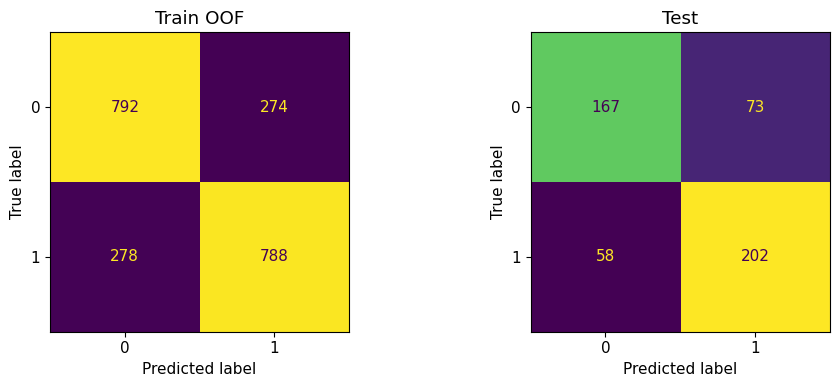


=== 카테고리별 Test 성능 ===
카테고리               n      AUC       F1
----------------------------------------
skincare         227   0.7819   0.7030
cleansing        146   0.8141   0.7184
masks             52   0.8785   0.7884
suncare           75   0.8896   0.8256
----------------------------------------
전체               500   0.8191   0.7367

=== 카테고리별 최적 F1 Threshold ===
카테고리              최적threshold    F1(macro)
--------------------------------------------
skincare                 0.36       0.7300
cleansing                0.44       0.7283
masks                    0.46       0.7884
suncare                  0.55       0.8386
=== 카테고리별 최적 threshold 적용 후 성능 ===
카테고리               n      AUC       F1   threshold
--------------------------------------------------
skincare         227   0.7819   0.7300        0.36
cleansing        146   0.8141   0.7283        0.44
masks             52   0.8785   0.7884        0.46
suncare           75   0.8896   0.8386        0.55
-----------------------------

In [59]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

best_params = {**study.best_params, 'random_state': 42, 'verbose': -1}
final_model = LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = final_model.predict(X_test)
test_auc   = roc_auc_score(y_test, test_proba)
train_auc  = study.best_value

print(f'Train CV AUC : {train_auc:.4f}')
print(f'Test AUC     : {test_auc:.4f}')
print(f'과적합 갭    : {train_auc - test_auc:+.4f}')

y_oof = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict')
print(f'\n[Train OOF] Classification Report:')
print(classification_report(y_train, y_oof))
print('[Test] Classification Report:')
print(classification_report(y_test, test_pred))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_oof, ax=axes[0], colorbar=False)
axes[0].set_title('Train OOF')
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[1], colorbar=False)
axes[1].set_title('Test')
plt.tight_layout()
plt.show()

# 카테고리별 Test 성능
print('\n=== 카테고리별 Test 성능 ===')
print(f'{"카테고리":<14} {"n":>5}  {"AUC":>7}  {"F1":>7}')
print('-' * 40)
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    mask = (test_cats_series == cat).values
    if mask.sum() == 0 or len(np.unique(y_test[mask])) < 2:
        continue
    cat_auc = roc_auc_score(y_test[mask], test_proba[mask])
    cat_f1  = f1_score(y_test[mask], test_pred[mask], average='macro')
    print(f'{cat:<14} {mask.sum():>5}  {cat_auc:>7.4f}  {cat_f1:>7.4f}')
print('-' * 40)
ovr_f1 = f1_score(y_test, test_pred, average='macro')
print(f'{"전체":<14} {len(y_test):>5}  {test_auc:>7.4f}  {ovr_f1:>7.4f}')

# 카테고리별 최적 F1 Threshold
print('\n=== 카테고리별 최적 F1 Threshold ===')
print(f'{"카테고리":<14} {"최적threshold":>14} {"F1(macro)":>12}')
print('-' * 44)
thr_range = np.arange(0.10, 0.91, 0.01)
best_thresholds = {}
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    mask = (test_cats_series == cat).values
    if mask.sum() == 0 or len(np.unique(y_test[mask])) < 2:
        continue
    f1s    = [f1_score(y_test[mask], (test_proba[mask] >= t).astype(int),
                       average='macro', zero_division=0) for t in thr_range]
    best_t = thr_range[np.argmax(f1s)]
    best_thresholds[cat] = best_t
    print(f'{cat:<14} {best_t:>14.2f} {max(f1s):>12.4f}')


# ── 카테고리별 최적 threshold 적용 ──────────────────────────
test_pred_cat = np.zeros(len(y_test), dtype=int)
for cat, thr in best_thresholds.items():
    mask = (test_cats_series == cat).values
    test_pred_cat[mask] = (test_proba[mask] >= thr).astype(int)

print('=== 카테고리별 최적 threshold 적용 후 성능 ===')
print(f'{"카테고리":<14} {"n":>5}  {"AUC":>7}  {"F1":>7}  {"threshold":>10}')
print('-' * 50)
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    mask = (test_cats_series == cat).values
    if mask.sum() == 0 or len(np.unique(y_test[mask])) < 2:
        continue
    cat_auc = roc_auc_score(y_test[mask], test_proba[mask])
    cat_f1  = f1_score(y_test[mask], test_pred_cat[mask], average='macro')
    thr     = best_thresholds.get(cat, 0.5)
    print(f'{cat:<14} {mask.sum():>5}  {cat_auc:>7.4f}  {cat_f1:>7.4f}  {thr:>10.2f}')
print('-' * 50)
ovr_f1_cat = f1_score(y_test, test_pred_cat, average='macro')
print(f'{"전체":<14} {len(y_test):>5}  {test_auc:>7.4f}  {ovr_f1_cat:>7.4f}')
print(f'F1 개선: {ovr_f1:.4f} → {ovr_f1_cat:.4f} ({ovr_f1_cat - ovr_f1:+.4f})')


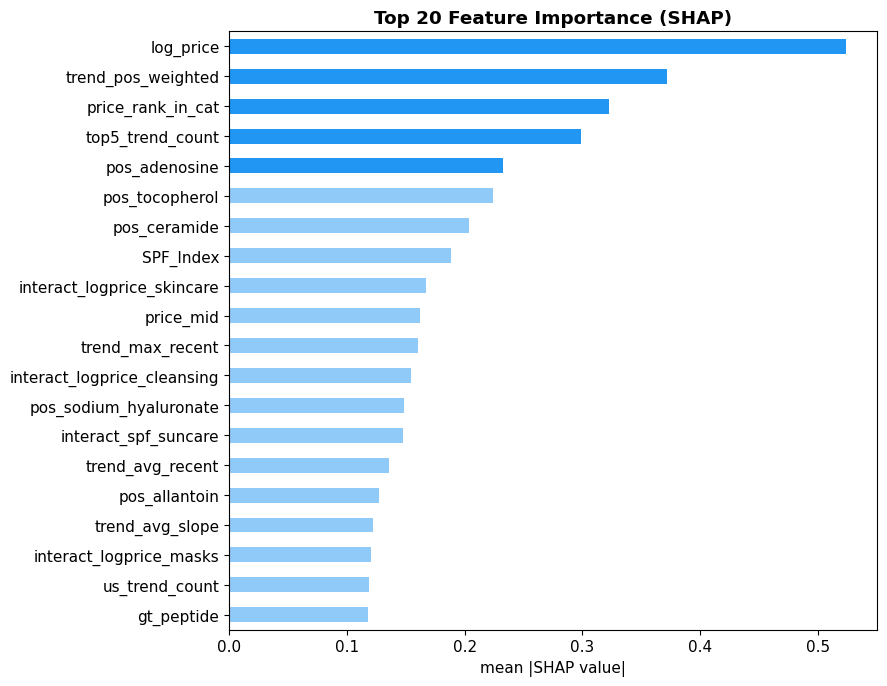

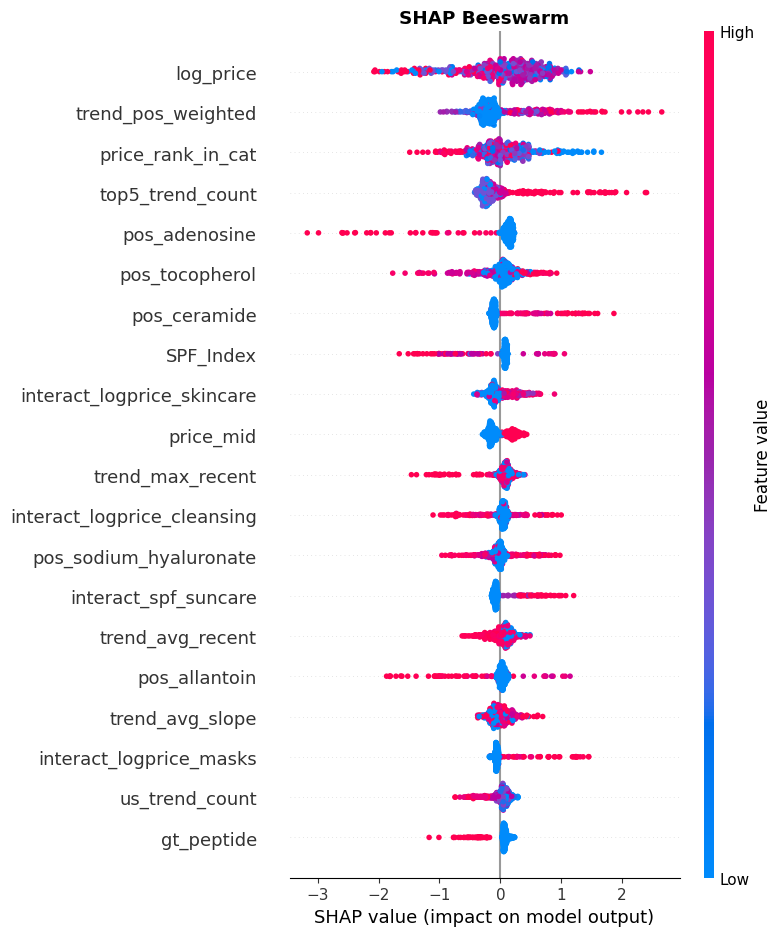

Top 15 피처 (SHAP):
  log_price                                     0.5241  (+)
  trend_pos_weighted                            0.3719  (+)
  price_rank_in_cat                             0.3222  (+)
  top5_trend_count                              0.2986  (-)
  pos_adenosine                                 0.2328  (+)
  pos_tocopherol                                0.2239  (+)
  pos_ceramide                                  0.2034  (+)
  SPF_Index                                     0.1880  (-)
  interact_logprice_skincare                    0.1672  (+)
  price_mid                                     0.1621  (-)
  trend_max_recent                              0.1603  (+)
  interact_logprice_cleansing                   0.1545  (-)
  pos_sodium_hyaluronate                        0.1481  (-)
  interact_spf_suncare                          0.1476  (+)
  trend_avg_recent                              0.1359  (+)


In [55]:
import shap

explainer  = shap.TreeExplainer(final_model)
shap_vals  = explainer.shap_values(X_test)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

mean_abs = pd.DataFrame(sv, columns=feat_cols).abs().mean().sort_values(ascending=False)
top20 = mean_abs.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2196F3' if i < 5 else '#90CAF9' for i in range(len(top20))]
top20.sort_values().plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_xlabel('mean |SHAP value|')
ax.set_title('Top 20 Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_v23.png', dpi=150, bbox_inches='tight')
plt.show()

X_test_df = pd.DataFrame(X_test, columns=feat_cols)
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test_df, max_display=20, show=False)
plt.title('SHAP Beeswarm', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_v23.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 피처 (SHAP):')
sv_df = pd.DataFrame(sv, columns=feat_cols)
for feat, val in mean_abs.head(15).items():
    direction = '(+)' if sv_df[feat].mean() > 0 else '(-)'
    print(f'  {feat:<45} {val:.4f}  {direction}')

In [56]:
# 전체 카테고리 오분류 패턴 분석
for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    cat_mask = (test_cats_series == cat).values
    if cat_mask.sum() == 0:
        continue

    cat_df = df_test[cat_mask].copy()
    cat_df['pred']  = test_pred[cat_mask]
    cat_df['proba'] = test_proba[cat_mask]

    fp = cat_df[(cat_df['target']==0) & (cat_df['pred']==1)]
    fn = cat_df[(cat_df['target']==1) & (cat_df['pred']==0)]
    tp = cat_df[(cat_df['target']==1) & (cat_df['pred']==1)]
    tn = cat_df[(cat_df['target']==0) & (cat_df['pred']==0)]

    print(f'\n{"="*60}')
    print(f'[{cat.upper()}]  전체={len(cat_df)}  FP={len(fp)}  FN={len(fn)}  정답={len(tp)+len(tn)}')
    print(f'{"="*60}')

    # 가격대별 오분류율
    print(f'\n  -- 가격대별 --')
    print(f"  {'구간':<12} {'전체':>5} {'FP':>5} {'FN':>5} {'오분류율':>8}  y_mean(FP)  y_mean(FN)")
    for label, mask in [('low($0-30)',  cat_df['공급가(USD)'] <= 30),
                        ('mid($30-71)', (cat_df['공급가(USD)'] > 30) & (cat_df['공급가(USD)'] <= 71)),
                        ('high($71+)',  cat_df['공급가(USD)'] > 71)]:
        sub = cat_df[mask]
        if len(sub) == 0: continue
        fp_n = ((sub['target']==0) & (sub['pred']==1)).sum()
        fn_n = ((sub['target']==1) & (sub['pred']==0)).sum()
        fp_ymean = sub[(sub['target']==0) & (sub['pred']==1)]['y_composite'].mean()
        fn_ymean = sub[(sub['target']==1) & (sub['pred']==0)]['y_composite'].mean()
        err = (fp_n + fn_n) / len(sub)
        print(f"  {label:<12} {len(sub):>5} {fp_n:>5} {fn_n:>5} {err:>8.1%}  {fp_ymean:>10.3f}  {fn_ymean:>10.3f}")

    # 카테고리(중)별 오분류율
    if cat_df['카테고리(중)'].nunique() > 1:
        print(f'\n  -- 카테고리(중)별 --')
        print(f"  {'카테고리(중)':<28} {'전체':>5} {'FP':>5} {'FN':>5} {'오분류율':>8}")
        for mid, grp in cat_df.groupby('카테고리(중)'):
            if len(grp) < 3: continue
            fp_n = ((grp['target']==0) & (grp['pred']==1)).sum()
            fn_n = ((grp['target']==1) & (grp['pred']==0)).sum()
            err = (fp_n + fn_n) / len(grp)
            print(f"  {str(mid):<28} {len(grp):>5} {fp_n:>5} {fn_n:>5} {err:>8.1%}")



[SKINCARE]  전체=227  FP=38  FN=29  정답=160

  -- 가격대별 --
  구간              전체    FP    FN     오분류율  y_mean(FP)  y_mean(FN)
  low($0-30)      91    11    10    23.1%       0.318       0.649
  mid($30-71)     80    18     8    32.5%       0.312       0.657
  high($71+)      56     9    11    35.7%       0.295       0.653

  -- 카테고리(중)별 --
  카테고리(중)                         전체    FP    FN     오분류율
  cream                           93    15    14    31.2%
  essence/serum/ampoule           66    13     9    33.3%
  eye care                        27     4     2    22.2%
  lotion                          12     0     0     0.0%
  mist/fixer                       7     2     1    42.9%
  moisturizer                      8     1     1    25.0%
  skin/toner                       7     1     1    28.6%
  toner                            5     0     1    20.0%

[CLEANSING]  전체=146  FP=21  FN=19  정답=106

  -- 가격대별 --
  구간              전체    FP    FN     오분류율  y_mean(FP)  y_mean(FN)
  low($0-30)     

In [69]:
import os, joblib

price_arrays = {
    cat: df_y.loc[df_y['target_category'] == cat, '공급가(USD)'].dropna().tolist()
    for cat in ['skincare', 'cleansing', 'masks', 'suncare']
}

save_dir = r'C:\workspace\finalproject\data\model_output'
os.makedirs(save_dir, exist_ok=True)

model_data = {
    'model':            final_model,
    'feat_cols':        feat_cols,
    'gt_map':           gt_map,
    'position_targets': position_targets,
    'price_arrays':     price_arrays,
    'cat_thresholds':   best_thresholds,
    'gt_trend_stats':  gt_trend_stats,   # 카테고리별 최적 threshold
}

save_path = os.path.join(save_dir, 'lgbm_v99.pkl')
joblib.dump(model_data, save_path)
print(f'모델 저장 완료: {save_path}')
print(f'피처 수: {len(feat_cols)}개')
print(f'카테고리별 threshold: {best_thresholds}')
print(f'Test AUC: {test_auc:.4f}')


모델 저장 완료: C:\workspace\finalproject\data\model_output\lgbm_v99.pkl
피처 수: 95개
카테고리별 threshold: {'skincare': 0.3599999999999999, 'cleansing': 0.43999999999999984, 'masks': 0.45999999999999985, 'suncare': 0.5499999999999998}
Test AUC: 0.8191


In [65]:
# ── 한국어 성분명 → 영문 변환 ──────────────────────────────
KOR_TO_INCI = {
    '정제수': 'water', '물': 'water',
    '글리세린': 'glycerin', '부틸렌글라이콜': 'butylene glycol',
    '에틸헥실글리세린': 'ethylhexylglycerin', '프로판다이올': 'propanediol',
    '나이아신아마이드': 'niacinamide', '소듐하이알루로네이트': 'sodium hyaluronate',
    '하이알루론산': 'hyaluronic acid', '판테놀': 'panthenol', '판토텐올': 'panthenol',
    '토코페롤': 'tocopherol', '토코페릴아세테이트': 'tocopheryl acetate',
    '세라마이드엔피': 'ceramide np', '세라마이드에이피': 'ceramide ap',
    '세라마이드이오피': 'ceramide eop', '병풀추출물': 'centella asiatica extract',
    '마데카소사이드': 'madecassoside', '아시아티코사이드': 'asiaticoside',
    '스쿠알란': 'squalane', '레티놀': 'retinol', '레티닐팔미테이트': 'retinyl palmitate',
    '살리실릭애씨드': 'salicylic acid', '글라이콜릭애씨드': 'glycolic acid',
    '락틱애씨드': 'lactic acid', '아젤라익애씨드': 'azelaic acid',
    '트라넥사믹애씨드': 'tranexamic acid', '알부틴': 'arbutin',
    '아스코빅애씨드': 'ascorbic acid', '비타민씨': 'ascorbic acid',
    '아데노신': 'adenosine', '카페인': 'caffeine', '펩타이드': 'peptide',
    '콜라겐': 'collagen', '베타글루칸': 'beta-glucan', '알란토인': 'allantoin',
    '비사보롤': 'bisabolol', '징크옥사이드': 'zinc oxide',
    '티타늄디옥사이드': 'titanium dioxide', '이산화티탄': 'titanium dioxide',
    '소듐코코일글루타메이트': 'sodium cocoyl glutamate',
    '소듐메칠코코일타우레이트': 'sodium methyl cocoyl taurate',
    '소듐라우로일글루타메이트': 'sodium lauroyl glutamate',
    '갈락토미세스발효여과물': 'galactomyces ferment filtrate',
    '비피다발효용해물': 'bifida ferment lysate',
    '락토바실러스': 'lactobacillus', '페녹시에탄올': 'phenoxyethanol',
    '다이소듐이디티에이': 'disodium edta', '카보머': 'carbomer',
    '잔탄검': 'xanthan gum', '하이드록시에틸셀룰로오스': 'hydroxyethylcellulose',
    '트로메타민': 'tromethamine', '소듐하이드록사이드': 'sodium hydroxide',
    '시트릭애씨드': 'citric acid',
}

def translate_ing(val):
    if not isinstance(val, str) or not val.strip():
        return val
    v = val.strip()
    if v in KOR_TO_INCI:
        return KOR_TO_INCI[v]
    v_lower = v.lower()
    for k, en in KOR_TO_INCI.items():
        if k in v_lower:
            return en
    return v

# ── 한국 상품 전체 추론 + 엑셀 저장 ──────────────────────────
from scipy.stats import percentileofscore
import numpy as np, pandas as pd, os

KRW_TO_USD = 1470

df_kr = pd.read_csv(
    r'C:\workspace\finalproject\data\musinsa_hwahae_oliveyoung.csv',
    encoding='utf-8', low_memory=False
)

# 카테고리 매핑
cat_map_kr = {
    '스킨케어': 'skincare', '클렌징': 'cleansing',
    '마스크': 'masks',      '썬케어': 'suncare',
    'skincare': 'skincare', 'cleansing': 'cleansing',
    'masks': 'masks',       'suncare': 'suncare',
}
df_kr['target_category'] = df_kr['target_category'].map(cat_map_kr)
df_kr = df_kr[df_kr['target_category'].notna()].copy()

# 가격 변환
df_kr['공급가(USD)'] = pd.to_numeric(df_kr['공급가(USD)'], errors='coerce').fillna(0) / KRW_TO_USD
df_kr['SPF_Index']   = pd.to_numeric(df_kr['SPF_Index'],   errors='coerce').fillna(0)

# 성분 컬럼
ing_cols_kr = [c for c in df_kr.columns if c.startswith('성분_')]

# 한국어 → 영문 번역 적용
for col in ing_cols_kr:
    df_kr[col] = df_kr[col].apply(translate_ing)

ing_lower_kr = df_kr[ing_cols_kr].fillna('').apply(lambda r: ' '.join(r).lower(), axis=1)

df_inf = df_kr.copy()

# ── 피처 생성 ──────────────────────────────────────────────
df_inf['log_price']         = np.log1p(df_inf['공급가(USD)'])
df_inf['price_rank_in_cat'] = df_inf.groupby('target_category')['공급가(USD)'].rank(pct=True)

price_d = pd.get_dummies(
    pd.cut(df_inf['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_inf = pd.concat([df_inf, price_d], axis=1)

cat_d = pd.get_dummies(df_inf['target_category'], prefix='cat').astype(int)
df_inf = pd.concat([df_inf, cat_d], axis=1)
for _c in ['skincare','cleansing','masks','suncare']:
    if f'cat_{_c}' not in df_inf.columns: df_inf[f'cat_{_c}'] = 0

for mv in [c.replace('mid_','') for c in feat_cols if c.startswith('mid_')]:
    df_inf[f'mid_{mv}'] = 0

for feat, kw in gt_map.items():
    df_inf[feat] = ing_lower_kr.str.contains(kw, regex=False).astype(int)
df_inf['us_trend_count'] = df_inf[list(gt_map.keys())].sum(axis=1)
df_inf['us_trend_ratio'] = df_inf['us_trend_count'] / len(gt_map)

top5_kws = ['niacinamide','ceramide','retinol','centella','bakuchiol']
df_inf['top5_trend_count'] = ing_lower_kr.apply(
    lambda t: sum(1 for kw in top5_kws if kw in t)
)

df_inf['SPF_Index'] = pd.to_numeric(df_inf['SPF_Index'], errors='coerce').fillna(0)
df_inf['spf_tier']  = pd.cut(
    df_inf['SPF_Index'], bins=[-1,0,30,50,9999], labels=[0,1,2,3]
).astype(float).fillna(0).astype(int)

# position 피처
total_ing_kr = df_inf[ing_cols_kr].notna().sum(axis=1).clip(lower=1)
for feat, pattern in position_targets.items():
    def get_pos(row, pat=pattern):
        ings = [str(v).lower() for v in row if pd.notna(v)]
        idx  = next((i for i, v in enumerate(ings) if pat in v), -1)
        return (1 - idx/len(ings)) if idx >= 0 else -1
    df_inf[f'pos_{feat}'] = df_inf[ing_cols_kr].apply(get_pos, axis=1)

for pf in [f'pos_{f}' for f in position_targets]:
    for cf in ['cat_skincare','cat_cleansing','cat_masks','cat_suncare']:
        df_inf[f'{pf}_x_{cf}'] = df_inf[pf].clip(lower=0) * df_inf[cf]

df_inf['is_amino_surfactant'] = ing_lower_kr.str.contains(
    r'sodium cocoyl|potassium cocoyl|sodium lauroyl|cocoamidopropyl betaine', regex=True).astype(int)
df_inf['is_sulfate']         = ing_lower_kr.str.contains(
    r'sodium lauryl sulfate|sodium laureth sulfate', regex=True).astype(int)
df_inf['is_salicylic']       = ing_lower_kr.str.contains('salicylic acid', regex=False).astype(int)
df_inf['is_physical_filter'] = ing_lower_kr.str.contains(
    r'zinc oxide|titanium dioxide', regex=True).astype(int)
df_inf['has_polyglyceryl']   = ing_lower_kr.str.contains('polyglyceryl', regex=False).astype(int)
df_inf['combo_adenosine_niacinamide'] = (
    ing_lower_kr.str.contains('adenosine',   regex=False) &
    ing_lower_kr.str.contains('niacinamide', regex=False)
).astype(int)
df_inf['combo_vitc_tocopherol'] = (
    ing_lower_kr.str.contains('ascorbic',   regex=False) &
    ing_lower_kr.str.contains('tocopherol', regex=False)
).astype(int)

# interact
for cat in ['skincare','cleansing','masks','suncare']:
    df_inf[f'interact_logprice_{cat}']   = df_inf['log_price']      * df_inf[f'cat_{cat}']
    df_inf[f'interact_trend_{cat}']      = df_inf['us_trend_ratio'] * df_inf[f'cat_{cat}']
    df_inf[f'interact_trendcount_{cat}'] = df_inf['us_trend_count'] * df_inf[f'cat_{cat}']

df_inf['interact_amino_cleansing']        = df_inf['is_amino_surfactant'] * df_inf['cat_cleansing']
df_inf['interact_salicylic_cleansing']    = df_inf['is_salicylic']        * df_inf['cat_cleansing']
df_inf['interact_physical_suncare']       = df_inf['is_physical_filter']  * df_inf['cat_suncare']
df_inf['interact_spf_suncare']            = df_inf['spf_tier']            * df_inf['cat_suncare']
df_inf['interact_top5trend_cleansing']    = df_inf['top5_trend_count']    * df_inf['cat_cleansing']
df_inf['interact_polyglyceryl_cleansing'] = df_inf['has_polyglyceryl']    * df_inf['cat_cleansing']
df_inf['interact_niacinamide_cleansing']  = df_inf['gt_niacinamide']      * df_inf['cat_cleansing']
df_inf['interact_hyaluronic_cleansing']   = df_inf['gt_sodium_hyaluronate'] * df_inf['cat_cleansing']

# GT 트렌드 피처
_gt_kw_map = {
    'gt_niacinamide':'niacinamide', 'gt_ceramide':'ceramide',
    'gt_sodium_hyaluronate':'sodium hyaluronate', 'gt_retinol':'retinol',
    'gt_peptide':'peptide', 'gt_vitamin_c':'ascorbic', 'gt_panthenol':'panthenol',
    'gt_centella':'centella', 'gt_bakuchiol':'bakuchiol',
    'gt_azelaic':'azelaic acid', 'gt_tranexamic':'tranexamic acid',
    'gt_salicylic':'salicylic acid', 'gt_squalane':'squalane',
}
_valid = {col: kw for col, kw in _gt_kw_map.items() if kw in gt_trend_stats}

def _gt_row(ing_str):
    matched = [kw for kw in _valid.values() if kw in ing_str]
    n = max(len(matched), 1)
    return pd.Series({
        'trend_max_recent':   max((gt_trend_stats[kw]['recent_12m'] for kw in matched), default=0),
        'trend_avg_recent':   sum(gt_trend_stats[kw]['recent_12m'] for kw in matched) / n,
        'trend_rising_count': sum(1 for kw in matched if gt_trend_stats[kw]['slope_12m'] > 0),
        'trend_avg_slope':    sum(gt_trend_stats[kw]['slope_12m'] for kw in matched) / n,
    })

gt_feats = ing_lower_kr.apply(_gt_row)
df_inf[gt_feats.columns] = gt_feats.values

_pos_map = {
    'gt_sodium_hyaluronate': 'pos_hyaluronic_acid',
    'gt_panthenol':          'pos_panthenol',
    'gt_ceramide':           'pos_ceramide',
}
df_inf['trend_pos_weighted'] = sum(
    df_inf[pc].clip(lower=0) * gt_trend_stats[_valid[gc]]['recent_12m']
    for gc, pc in _pos_map.items() if gc in _valid and pc in df_inf.columns
)

# ── 추론 ───────────────────────────────────────────────────
X_inf      = df_inf.reindex(columns=feat_cols).fillna(0).astype(float).values
us_scores  = final_model.predict_proba(X_train)[:, 1]
raw_scores = final_model.predict_proba(X_inf)[:, 1]

df_kr['fit_score'] = [
    round(percentileofscore(us_scores, s, kind='rank'), 1)
    for s in raw_scores
]
df_kr['raw_score']  = raw_scores.round(4)
df_kr['판정'] = df_kr.apply(
    lambda r: '적합' if r['raw_score'] >= best_thresholds.get(r['target_category'], 0.5) else '부적합',
    axis=1
)

# ── 결과 출력 ──────────────────────────────────────────────
print('=== 카테고리별 fit_score 분포 ===')
for kor, eng in [('스킨케어','skincare'),('클렌징','cleansing'),('마스크','masks'),('선케어','suncare')]:
    sub = df_kr[df_kr['target_category']==eng]['fit_score']
    if len(sub) == 0: continue
    print(f'{kor:<6} n={len(sub):4d}  평균={sub.mean():.1f}  상위10%≥{sub.quantile(0.9):.1f}  최고={sub.max():.1f}')

name_col  = next((c for c in df_kr.columns if '상품명' in c or '제품명' in c), None)
brand_col = next((c for c in df_kr.columns if '브랜드' in c), None)
show = [c for c in [name_col, brand_col, 'target_category', '공급가(USD)', 'fit_score', '판정'] if c]
print('\n=== 상위 20개 ===')
print(df_kr.nlargest(20, 'fit_score')[show].to_string(index=False))

# ── 엑셀 저장 ──────────────────────────────────────────────
save_dir  = r'C:\workspace\finalproject\data\model_output'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'korean_fit_score_v99.xlsx')

out_cols = [c for c in [name_col, brand_col, 'target_category', '카테고리(중)',
                         '공급가(USD)', 'SPF_Index', 'fit_score', 'raw_score', '판정'] if c]
df_kr[out_cols].sort_values('fit_score', ascending=False).to_excel(save_path, index=False)
print(f'\n저장 완료: {save_path}')
print(f'총 {len(df_kr)}개 제품')


=== 카테고리별 fit_score 분포 ===
스킨케어   n=1394  평균=32.8  상위10%≥55.2  최고=81.8
클렌징    n= 930  평균=38.8  상위10%≥51.5  최고=71.2
마스크    n=1057  평균=24.6  상위10%≥52.5  최고=87.8
선케어    n= 779  평균=20.9  상위10%≥46.2  최고=68.4

=== 상위 20개 ===
                                                               상품명  브랜드명 target_category  공급가(USD)  fit_score 판정
레드 락토 콜라겐 랩핑 마스크 70ml X2개 + 엑스트라 랩핑 마스크 15ml + 듀얼 브러쉬/ 물광 모공 리프팅 팩   메디필           masks 38.095238       87.8 적합
                                 플리프 시카-알로에 앰플 토너 200ml (여드름성피부추천)   플리프        skincare 12.244898       81.8 적합
                       [단독구성] 순한 마스크 40매 (5종 中 택1) + 비건라이스 크림 40ml    구달           masks 38.095238       78.1 적합
                                               비피다 바이옴 앰플 토너 210ml  마녀공장        skincare 10.204082       75.0 적합
                             [SET] 1025 독도 수분 선물 세트 (토너 + 로션 + 크림)  라운드랩        skincare 37.414966       74.9 적합
                                   디오디너리 설퍼 10% 파우더-투-크림 컨센트레이트 5g 디오디너리        skincare 10.204082     

In [64]:
# ── merged_with_derived.csv 전체 추론 + 엑셀 저장 ──────────
from scipy.stats import percentileofscore
import numpy as np, pandas as pd, os

df_m = pd.read_csv(
    r'C:\workspace\finalproject\real_data\merged_with_derived.csv',
    encoding='cp949', low_memory=False
)

# 카테고리 통일
cat_map_m = {
    'Cleansing': 'cleansing', 'Mask & Pack': 'masks',
    'Skin Care': 'skincare',  'Sun Care':    'suncare',
    'Skincare':  'skincare',  'skincare':    'skincare',
    'cleansing': 'cleansing', 'masks':       'masks',
    'suncare':   'suncare',
}
df_m['target_category'] = df_m['카테고리(대)'].map(cat_map_m)
df_m = df_m[df_m['target_category'].notna()].copy()
df_m['공급가(USD)'] = pd.to_numeric(df_m['공급가(USD)'], errors='coerce').fillna(0)
df_m['SPF_Index']   = pd.to_numeric(df_m['SPF_Index'],   errors='coerce').fillna(0)

ing_cols_m   = [c for c in df_m.columns if c.startswith('성분_')]
ing_lower_m  = df_m[ing_cols_m].fillna('').apply(lambda r: ' '.join(r).lower(), axis=1)

df_inf2 = df_m.copy()

# ── 피처 생성 ──────────────────────────────────────────────
df_inf2['log_price']         = np.log1p(df_inf2['공급가(USD)'])
df_inf2['price_rank_in_cat'] = df_inf2.groupby('target_category')['공급가(USD)'].rank(pct=True)

price_d = pd.get_dummies(
    pd.cut(df_inf2['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_inf2 = pd.concat([df_inf2, price_d], axis=1)

cat_d = pd.get_dummies(df_inf2['target_category'], prefix='cat').astype(int)
df_inf2 = pd.concat([df_inf2, cat_d], axis=1)
for _c in ['skincare','cleansing','masks','suncare']:
    if f'cat_{_c}' not in df_inf2.columns: df_inf2[f'cat_{_c}'] = 0

for mv in [c.replace('mid_','') for c in feat_cols if c.startswith('mid_')]:
    df_inf2[f'mid_{mv}'] = 0

for feat, kw in gt_map.items():
    df_inf2[feat] = ing_lower_m.str.contains(kw, regex=False).astype(int)
df_inf2['us_trend_count'] = df_inf2[list(gt_map.keys())].sum(axis=1)
df_inf2['us_trend_ratio'] = df_inf2['us_trend_count'] / len(gt_map)

top5_kws = ['niacinamide','ceramide','retinol','centella','bakuchiol']
df_inf2['top5_trend_count'] = ing_lower_m.apply(
    lambda t: sum(1 for kw in top5_kws if kw in t)
)

df_inf2['spf_tier'] = pd.cut(
    df_inf2['SPF_Index'], bins=[-1,0,30,50,9999], labels=[0,1,2,3]
).astype(float).fillna(0).astype(int)

for feat, pattern in position_targets.items():
    def get_pos(row, pat=pattern):
        ings = [str(v).lower() for v in row if pd.notna(v) and str(v).strip()]
        idx  = next((i for i, v in enumerate(ings) if pat in v), -1)
        return (1 - idx/max(len(ings),1)) if idx >= 0 else -1
    df_inf2[f'pos_{feat}'] = df_inf2[ing_cols_m].apply(get_pos, axis=1)

for pf in [f'pos_{f}' for f in position_targets]:
    for cf in ['cat_skincare','cat_cleansing','cat_masks','cat_suncare']:
        df_inf2[f'{pf}_x_{cf}'] = df_inf2[pf].clip(lower=0) * df_inf2[cf]

df_inf2['is_amino_surfactant'] = ing_lower_m.str.contains(
    r'sodium cocoyl|potassium cocoyl|sodium lauroyl|cocoamidopropyl betaine', regex=True).astype(int)
df_inf2['is_sulfate']         = ing_lower_m.str.contains(
    r'sodium lauryl sulfate|sodium laureth sulfate', regex=True).astype(int)
df_inf2['is_salicylic']       = ing_lower_m.str.contains('salicylic acid', regex=False).astype(int)
df_inf2['is_physical_filter'] = ing_lower_m.str.contains(
    r'zinc oxide|titanium dioxide', regex=True).astype(int)
df_inf2['has_polyglyceryl']   = ing_lower_m.str.contains('polyglyceryl', regex=False).astype(int)
df_inf2['combo_adenosine_niacinamide'] = (
    ing_lower_m.str.contains('adenosine',   regex=False) &
    ing_lower_m.str.contains('niacinamide', regex=False)
).astype(int)
df_inf2['combo_vitc_tocopherol'] = (
    ing_lower_m.str.contains('ascorbic',   regex=False) &
    ing_lower_m.str.contains('tocopherol', regex=False)
).astype(int)

for cat in ['skincare','cleansing','masks','suncare']:
    df_inf2[f'interact_logprice_{cat}']   = df_inf2['log_price']      * df_inf2[f'cat_{cat}']
    df_inf2[f'interact_trend_{cat}']      = df_inf2['us_trend_ratio'] * df_inf2[f'cat_{cat}']
    df_inf2[f'interact_trendcount_{cat}'] = df_inf2['us_trend_count'] * df_inf2[f'cat_{cat}']

df_inf2['interact_amino_cleansing']        = df_inf2['is_amino_surfactant'] * df_inf2['cat_cleansing']
df_inf2['interact_salicylic_cleansing']    = df_inf2['is_salicylic']        * df_inf2['cat_cleansing']
df_inf2['interact_physical_suncare']       = df_inf2['is_physical_filter']  * df_inf2['cat_suncare']
df_inf2['interact_spf_suncare']            = df_inf2['spf_tier']            * df_inf2['cat_suncare']
df_inf2['interact_top5trend_cleansing']    = df_inf2['top5_trend_count']    * df_inf2['cat_cleansing']
df_inf2['interact_polyglyceryl_cleansing'] = df_inf2['has_polyglyceryl']    * df_inf2['cat_cleansing']
df_inf2['interact_niacinamide_cleansing']  = df_inf2['gt_niacinamide']      * df_inf2['cat_cleansing']
df_inf2['interact_hyaluronic_cleansing']   = df_inf2['gt_sodium_hyaluronate'] * df_inf2['cat_cleansing']

_gt_kw_map = {
    'gt_niacinamide':'niacinamide', 'gt_ceramide':'ceramide',
    'gt_sodium_hyaluronate':'sodium hyaluronate', 'gt_retinol':'retinol',
    'gt_peptide':'peptide', 'gt_vitamin_c':'ascorbic', 'gt_panthenol':'panthenol',
    'gt_centella':'centella', 'gt_bakuchiol':'bakuchiol',
    'gt_azelaic':'azelaic acid', 'gt_tranexamic':'tranexamic acid',
    'gt_salicylic':'salicylic acid', 'gt_squalane':'squalane',
}
_valid = {col: kw for col, kw in _gt_kw_map.items() if kw in gt_trend_stats}

def _gt_row2(ing_str):
    matched = [kw for kw in _valid.values() if kw in ing_str]
    n = max(len(matched), 1)
    return pd.Series({
        'trend_max_recent':   max((gt_trend_stats[kw]['recent_12m'] for kw in matched), default=0),
        'trend_avg_recent':   sum(gt_trend_stats[kw]['recent_12m'] for kw in matched) / n,
        'trend_rising_count': sum(1 for kw in matched if gt_trend_stats[kw]['slope_12m'] > 0),
        'trend_avg_slope':    sum(gt_trend_stats[kw]['slope_12m'] for kw in matched) / n,
    })

gt_feats2 = ing_lower_m.apply(_gt_row2)
df_inf2[gt_feats2.columns] = gt_feats2.values

_pos_map = {
    'gt_sodium_hyaluronate': 'pos_hyaluronic_acid',
    'gt_panthenol':          'pos_panthenol',
    'gt_ceramide':           'pos_ceramide',
}
df_inf2['trend_pos_weighted'] = sum(
    df_inf2[pc].clip(lower=0) * gt_trend_stats[_valid[gc]]['recent_12m']
    for gc, pc in _pos_map.items() if gc in _valid and pc in df_inf2.columns
)

# ── 추론 ───────────────────────────────────────────────────
X_inf2     = df_inf2.reindex(columns=feat_cols).fillna(0).astype(float).values
us_scores  = final_model.predict_proba(X_train)[:, 1]
raw_scores2 = final_model.predict_proba(X_inf2)[:, 1]

df_m['fit_score'] = [
    round(percentileofscore(us_scores, s, kind='rank'), 1)
    for s in raw_scores2
]
df_m['raw_score'] = raw_scores2.round(4)
df_m['판정'] = df_m.apply(
    lambda r: '적합' if r['raw_score'] >= best_thresholds.get(r['target_category'], 0.5) else '부적합',
    axis=1
)

# ── 결과 출력 ──────────────────────────────────────────────
print('=== 카테고리별 fit_score 분포 ===')
for kor, eng in [('스킨케어','skincare'),('클렌징','cleansing'),('마스크','masks'),('선케어','suncare')]:
    sub = df_m[df_m['target_category']==eng]['fit_score']
    if len(sub)==0: continue
    print(f'{kor:<6} n={len(sub):4d}  평균={sub.mean():.1f}  상위10%≥{sub.quantile(0.9):.1f}  최고={sub.max():.1f}')

show = [c for c in ['상품명','브랜드명','store_id','target_category','공급가(USD)','fit_score','판정'] if c in df_m.columns]
print('\n=== 상위 20개 ===')
print(df_m.nlargest(20, 'fit_score')[show].to_string(index=False))

# ── 엑셀 저장 ──────────────────────────────────────────────
save_dir  = r'C:\workspace\finalproject\data\model_output'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'merged_fit_score_v99.xlsx')

out_cols = [c for c in ['상품명','브랜드명','store_id','target_category','카테고리(중)',
                          '공급가(USD)','SPF_Index','fit_score','raw_score','판정'] if c in df_m.columns]
df_m[out_cols].sort_values('fit_score', ascending=False).to_excel(save_path, index=False)
print(f'\n저장 완료: {save_path}')
print(f'총 {len(df_m)}개 제품')


=== 카테고리별 fit_score 분포 ===
스킨케어   n=1719  평균=39.1  상위10%≥59.4  최고=90.9
클렌징    n= 774  평균=38.2  상위10%≥55.3  최고=82.6
마스크    n= 307  평균=33.9  상위10%≥56.1  최고=88.5
선케어    n= 494  평균=41.9  상위10%≥66.3  최고=89.8

=== 상위 20개 ===
                                                                                     상품명                     브랜드명     store_id target_category  공급가(USD)  fit_score 판정
                                               alpha beta pore perfecting refining serum dr dennis gross skincare sephora_0425        skincare     68.00       90.9 적합
                                  protect glow daily sunscreen gel broad spectrum spf 30                     tula         ulta         suncare     58.00       89.8 적합
                                                     porescreen mineral sunscreen spf 40              dermalogica         ulta         suncare     57.00       89.7 적합
                                                     real niacinamide glow up daily mask                   neogen

In [67]:
from scipy.stats import percentileofscore
import numpy as np, pandas as pd

test_name      = '아누아 어성초 77 히알루론산 수분 진정 토너'
test_ings = [
    'Houttuynia Cordata Flower/Leaf/Stem Water', 'Water', '1,2-Hexanediol',
    'Glycerin', 'Glycereth-26', 'Betaine', 'Pentylene Glycol',
    'Sodium Citrate', 'Isopentyl Diol', 'Ethylhexylglycerin',
    'Dipotassium Glycyrrhizate', 'Citric Acid',
    'Acrylates/C10-30 Alkyl Acrylate Crosspolymer', 'Tromethamine',
    'Panthenol', 'Sodium Phytate', 'Allantoin', 'Sodium Hyaluronate',
    'Houttuynia Cordata Liposome', 'Hydrolyzed Sodium Hyaluronate',
    'Zinc PCA', 'Hydroxypropyltrimonium Hyaluronate',
    'Lactobacillus Ferment', 'Sodium Acetylated Hyaluronate',
    'Hydrolyzed Hyaluronic Acid', 'Isoquercitrin', 'Quercetin',
    'Hyaluronic Acid', 'Sodium Hyaluronate Crosspolymer',
    'Potassium Hyaluronate',
]
test_price_usd = 33.0
test_category  = 'skincare'
test_spf       = 0

ing_t_str    = ' '.join(str(v).lower() for v in test_ings if pd.notna(v))
test_ings_en = [str(v).lower() for v in test_ings if pd.notna(v)]
total_t      = len(test_ings)

row = {'target_category': test_category, '공급가(USD)': test_price_usd, 'SPF_Index': test_spf}
for i, ing in enumerate(test_ings, 1):
    row[f'성분_{i}'] = ing
df_t = pd.DataFrame([row])

ing_cols_t = [f'성분_{i}' for i in range(1, 116)]
for col in ing_cols_t:
    if col not in df_t.columns: df_t[col] = np.nan

if test_price_usd <= 30:
    df_t['price_low'], df_t['price_mid'], df_t['price_high'] = 1, 0, 0
elif test_price_usd <= 71:
    df_t['price_low'], df_t['price_mid'], df_t['price_high'] = 0, 1, 0
else:
    df_t['price_low'], df_t['price_mid'], df_t['price_high'] = 0, 0, 1

df_t['log_price']         = np.log1p(test_price_usd)
df_t['price_rank_in_cat'] = 0.4
df_t['SPF_Index']         = float(test_spf)
df_t['spf_tier']          = 0

for c in ['cat_skincare','cat_cleansing','cat_masks','cat_suncare']:
    df_t[c] = 0
df_t[f'cat_{test_category}'] = 1

for mv in [c.replace('mid_','') for c in feat_cols if c.startswith('mid_')]:
    df_t[f'mid_{mv}'] = 0

for feat, kw in gt_map.items():
    df_t[feat] = int(kw in ing_t_str)
df_t['us_trend_count'] = df_t[list(gt_map.keys())].sum(axis=1)
df_t['us_trend_ratio'] = df_t['us_trend_count'] / len(gt_map)

top5_kws = ['niacinamide','ceramide','retinol','centella','bakuchiol']
df_t['top5_trend_count'] = sum(int(kw in ing_t_str) for kw in top5_kws)

for feat, pattern in position_targets.items():
    idx = next((i for i, v in enumerate(test_ings_en) if pattern in v), -1)
    df_t[f'pos_{feat}'] = (1 - idx / total_t) if idx >= 0 else -1

for pf in [f'pos_{f}' for f in position_targets]:
    for cf in ['cat_skincare','cat_cleansing','cat_masks','cat_suncare']:
        df_t[f'{pf}_x_{cf}'] = max(df_t[pf].iloc[0], 0) * df_t[cf].iloc[0]

df_t['is_amino_surfactant'] = int(bool(pd.Series([ing_t_str]).str.contains(
    r'sodium cocoyl|potassium cocoyl|sodium lauroyl|cocoamidopropyl betaine', regex=True).iloc[0]))
df_t['is_sulfate']   = int('sodium lauryl sulfate' in ing_t_str or 'sodium laureth sulfate' in ing_t_str)
df_t['is_salicylic'] = int('salicylic acid' in ing_t_str)
df_t['is_physical_filter']  = int('zinc oxide' in ing_t_str or 'titanium dioxide' in ing_t_str)
df_t['has_polyglyceryl']    = int('polyglyceryl' in ing_t_str)
df_t['combo_adenosine_niacinamide'] = int('adenosine' in ing_t_str and 'niacinamide' in ing_t_str)
df_t['combo_vitc_tocopherol']       = int('ascorbic' in ing_t_str and 'tocopherol' in ing_t_str)

_gt_kw_map = {
    'gt_niacinamide':'niacinamide', 'gt_ceramide':'ceramide',
    'gt_sodium_hyaluronate':'sodium hyaluronate', 'gt_retinol':'retinol',
    'gt_peptide':'peptide', 'gt_vitamin_c':'ascorbic', 'gt_panthenol':'panthenol',
    'gt_centella':'centella', 'gt_bakuchiol':'bakuchiol',
    'gt_azelaic':'azelaic acid', 'gt_tranexamic':'tranexamic acid',
    'gt_salicylic':'salicylic acid', 'gt_squalane':'squalane',
}
_valid   = {col: kw for col, kw in _gt_kw_map.items() if kw in gt_trend_stats}
_matched = [kw for kw in _valid.values() if kw in ing_t_str]
_npres   = max(len(_matched), 1)

df_t['trend_max_recent']   = max((gt_trend_stats[kw]['recent_12m'] for kw in _matched), default=0)
df_t['trend_avg_recent']   = sum(gt_trend_stats[kw]['recent_12m'] for kw in _matched) / _npres
df_t['trend_rising_count'] = sum(1 for kw in _matched if gt_trend_stats[kw]['slope_12m'] > 0)
df_t['trend_avg_slope']    = sum(gt_trend_stats[kw]['slope_12m'] for kw in _matched) / _npres

_pos_map = {
    'gt_panthenol':          'pos_panthenol',
    'gt_ceramide':           'pos_ceramide',
    'gt_sodium_hyaluronate': 'pos_hyaluronic_acid',
    'gt_centella':           'pos_centella_asiatica' if 'pos_centella_asiatica' in feat_cols else 'pos_centella',
}
tpw = 0
for gc, pc in _pos_map.items():
    if gc in _valid and pc in df_t.columns:
        tpw += max(df_t[pc].iloc[0], 0) * gt_trend_stats[_valid[gc]]['recent_12m']
df_t['trend_pos_weighted'] = tpw

for cat in ['skincare','cleansing','masks','suncare']:
    df_t[f'interact_logprice_{cat}']   = df_t['log_price']      * df_t[f'cat_{cat}']
    df_t[f'interact_trend_{cat}']      = df_t['us_trend_ratio'] * df_t[f'cat_{cat}']
    df_t[f'interact_trendcount_{cat}'] = df_t['us_trend_count'] * df_t[f'cat_{cat}']

df_t['interact_amino_cleansing']        = 0
df_t['interact_salicylic_cleansing']    = 0
df_t['interact_physical_suncare']       = 0
df_t['interact_spf_suncare']            = 0
df_t['interact_top5trend_cleansing']    = 0
df_t['interact_polyglyceryl_cleansing'] = 0
df_t['interact_niacinamide_cleansing']  = 0
df_t['interact_hyaluronic_cleansing']   = 0

X_t        = df_t.reindex(columns=feat_cols).fillna(0).astype(float).values
raw_score  = final_model.predict_proba(X_t)[0, 1]
us_scores  = final_model.predict_proba(X_train)[:, 1]
calibrated = round(percentileofscore(us_scores, raw_score, kind='rank'), 1)
threshold  = best_thresholds.get(test_category, 0.5)

print(f"\n{'='*52}")
print(f"  제품: {test_name}")
print(f"  카테고리: {test_category}  |  가격: ${test_price_usd}")
print(f"  GT 트렌드 성분: {df_t['us_trend_count'].iloc[0]:.0f}개  "
      f"매칭: {[kw for col, kw in gt_map.items() if df_t[col].iloc[0]==1]}")
print(f"{'='*52}")
print(f"  raw score  : {raw_score:.4f}  (threshold: {threshold})")
print(f"  판정       : {'✅ 시장 적합' if raw_score >= threshold else '❌ 부적합'}")
print(f"  보정 점수  : {calibrated:.1f}점 / 100점")
print(f"{'='*52}")



  제품: 아누아 어성초 77 히알루론산 수분 진정 토너
  카테고리: skincare  |  가격: $33.0
  GT 트렌드 성분: 2개  매칭: ['sodium hyaluronate', 'panthenol']
  raw score  : 0.8796  (threshold: 0.3599999999999999)
  판정       : ✅ 시장 적합
  보정 점수  : 67.3점 / 100점
